In [1]:
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
from salishsea_tools import viz_tools, places,geo_tools, bloomdrivers as bd, evaltools as et
import xarray as xr
import datetime as dt
%matplotlib inline

### Load watermasks for pre- and post-September 2011 HRDPS grid

In [2]:
Watermask1 = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/GEM_watermask_for_gem_files_pre_22sep11.nc')
Watermask2 = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/GEM_watermask_for_gem_files_22sep11_onward.nc')
Watermask3 = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/GEM_watermask_for_continental_files.nc')


In [3]:
# get grid corners (use 2015, pre Sept 22, 2011 and post Sept 22 2011 files)

<class 'netCDF4._netCDF4.Variable'>
float64 u_wind(time_counter, y, x)
    _FillValue: nan
    GRIB_paramId: 165
    GRIB_dataType: af
    GRIB_numberOfPoints: 43700LL
    GRIB_typeOfLevel: heightAboveGround
    GRIB_stepUnits: 1
    GRIB_stepType: instant
    GRIB_gridType: rotated_ll
    GRIB_NV: 0
    GRIB_Nx: 230LL
    GRIB_Ny: 190LL
    GRIB_angleOfRotationInDegrees: 0.0
    GRIB_cfName: eastward_wind
    GRIB_cfVarName: u10
    GRIB_gridDefinitionDescription: Rotated latitude/longitude
    GRIB_iDirectionIncrementInDegrees: 0.0225
    GRIB_iScansNegatively: 0
    GRIB_jDirectionIncrementInDegrees: 0.0225
    GRIB_jPointsAreConsecutive: 0
    GRIB_jScansPositively: 1
    GRIB_latitudeOfFirstGridPointInDegrees: -12.302501
    GRIB_latitudeOfLastGridPointInDegrees: 16.700001
    GRIB_latitudeOfSouthernPoleInDegrees: -36.08852
    GRIB_longitudeOfFirstGridPointInDegrees: 345.17878
    GRIB_longitudeOfLastGridPointInDegrees: 42.306283
    GRIB_longitudeOfSouthernPoleInDegrees: 245.305

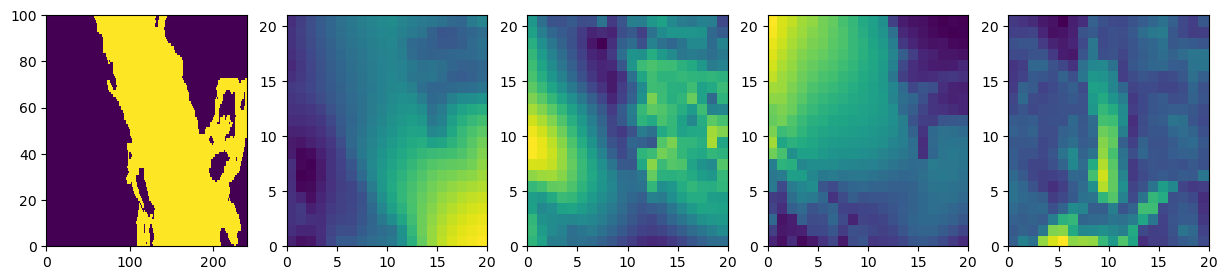

In [4]:
fig,ax=plt.subplots(1,5,figsize=(15,3))
with nc.Dataset('/data/eolson/results/MEOPAR/NEMO-forcing-new/grid/mesh_mask201702.nc') as mesh:
    navlon=mesh.variables['nav_lon'][:,:]
    navlat=mesh.variables['nav_lat'][:,:]
    tmask=mesh.variables['tmask'][0,:,:,:]
    ax[0].pcolormesh(mesh.variables['tmask'][0,0,450:550,110:350])
with nc.Dataset('/results/forcing/atmospheric/GEM2.5/operational/ops_y2015m03d01.nc') as g:
    ops_lon=g.variables['nav_lon'][:,:]
    ops_lat=g.variables['nav_lat'][:,:]
    ax[1].pcolormesh((g.variables['u_wind'][0,119:140,143:163]**2+\
                      g.variables['v_wind'][0,119:140,143:163]**2)**(1/2))
    #.pcolormesh(g.variables[])
with nc.Dataset('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m09d21.nc') as g: 
    gl1_lon=g.variables['nav_lon'][:,:]
    gl1_lat=g.variables['nav_lat'][:,:]
    ax[2].pcolormesh((g.variables['u_wind'][0,119:140,143:163]**2+\
                      g.variables['v_wind'][0,119:140,143:163]**2)**(1/2))
with nc.Dataset('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m09d22.nc') as g: 
    gl2_lon=g.variables['nav_lon'][:,:]
    gl2_lat=g.variables['nav_lat'][:,:]
    ax[3].pcolormesh((g.variables['u_wind'][0,119:140,143:163]**2+\
                      g.variables['v_wind'][0,119:140,143:163]**2)**(1/2))
with nc.Dataset('/results/forcing/atmospheric/continental2.5/nemo_forcing/hrdps_y2023m02d23.nc') as g: 
    con_lon=g.variables['nav_lon'][:,:]
    con_lat=g.variables['nav_lat'][:,:]
    ax[4].pcolormesh((g.variables['u_wind'][0,119:140,143:163]**2+\
                      g.variables['v_wind'][0,119:140,143:163]**2)**(1/2))
    print(g.variables['u_wind'])

In [5]:
ll_lon=navlon[450,110]
lr_lon=navlon[450,350]
ul_lon=navlon[550,110]
ur_lon=navlon[550,350]
ll_lat=navlat[450,110]
lr_lat=navlat[450,350]
ul_lat=navlat[550,110]
ur_lat=navlat[550,350]

In [6]:
(ll_j_ops,ll_i_ops)=geo_tools.find_closest_model_point(ll_lon,ll_lat,ops_lon-360,ops_lat,grid='GEM2.5')
(lr_j_ops,lr_i_ops)=geo_tools.find_closest_model_point(lr_lon,lr_lat,ops_lon-360,ops_lat,grid='GEM2.5')
(ul_j_ops,ul_i_ops)=geo_tools.find_closest_model_point(ul_lon,ul_lat,ops_lon-360,ops_lat,grid='GEM2.5')
(ur_j_ops,ur_i_ops)=geo_tools.find_closest_model_point(ur_lon,ur_lat,ops_lon-360,ops_lat,grid='GEM2.5')
print((ll_j_ops,ll_i_ops),(lr_j_ops,lr_i_ops),(ul_j_ops,ul_i_ops),(ur_j_ops,ur_i_ops))

(130, 118) (144, 160) (150, 111) (163, 153)


In [7]:
(ll_j_gl1,ll_i_gl1)=geo_tools.find_closest_model_point(ll_lon,ll_lat,gl1_lon-360,gl1_lat,grid='GEM2.5')
(lr_j_gl1,lr_i_gl1)=geo_tools.find_closest_model_point(lr_lon,lr_lat,gl1_lon-360,gl2_lat,grid='GEM2.5')
(ul_j_gl1,ul_i_gl1)=geo_tools.find_closest_model_point(ul_lon,ul_lat,gl1_lon-360,gl1_lat,grid='GEM2.5')
(ur_j_gl1,ur_i_gl1)=geo_tools.find_closest_model_point(ur_lon,ur_lat,gl1_lon-360,gl1_lat,grid='GEM2.5')
print((ll_j_gl1,ll_i_gl1),(lr_j_gl1,lr_i_gl1),(ul_j_gl1,ul_i_gl1),(ur_j_gl1,ur_i_gl1))

(123, 117) (141, 157) (142, 111) (156, 150)


In [8]:
(ll_j_gl2,ll_i_gl2)=geo_tools.find_closest_model_point(ll_lon,ll_lat,gl2_lon-360,gl2_lat,grid='GEM2.5')
(lr_j_gl2,lr_i_gl2)=geo_tools.find_closest_model_point(lr_lon,lr_lat,gl2_lon-360,gl2_lat,grid='GEM2.5')
(ul_j_gl2,ul_i_gl2)=geo_tools.find_closest_model_point(ul_lon,ul_lat,gl2_lon-360,gl2_lat,grid='GEM2.5')
(ur_j_gl2,ur_i_gl2)=geo_tools.find_closest_model_point(ur_lon,ur_lat,gl2_lon-360,gl2_lat,grid='GEM2.5')
print((ll_j_gl2,ll_i_gl2),(lr_j_gl2,lr_i_gl2),(ul_j_gl2,ul_i_gl2),(ur_j_gl2,ur_i_gl2))

(127, 121) (141, 160) (146, 114) (159, 153)


In [9]:
(ll_j_con,ll_i_con)=geo_tools.find_closest_model_point(ll_lon,ll_lat,con_lon-360,con_lat,grid='continental2.5')
(lr_j_con,lr_i_con)=geo_tools.find_closest_model_point(lr_lon,lr_lat,con_lon-360,con_lat,grid='continental2.5')
(ul_j_con,ul_i_con)=geo_tools.find_closest_model_point(ul_lon,ul_lat,con_lon-360,con_lat,grid='continental2.5')
(ur_j_con,ur_i_con)=geo_tools.find_closest_model_point(ur_lon,ur_lat,con_lon-360,con_lat,grid='continental2.5')
print((ll_j_con,ll_i_con),(lr_j_con,lr_i_con),(ul_j_con,ul_i_con),(ur_j_con,ur_i_con))

(111, 77) (126, 116) (129, 70) (145, 108)


In [10]:
# ops: use j: 130:163, i: 111:160
# gl1: use j: 123:156, i: 111:157
# gl2: use j: 127:159, i: 114:160
# con: use j: 111:145, i: 70:116

In [11]:
def getWindVars(day):
    if day>dt.datetime(2023,2,23): #or day.year>2014
        opsdir='/results/forcing/atmospheric/continental2.5/nemo_forcing'
        nam_fmt='hrdps'
        jlims=(111,145)
        ilims=(70,116)
    
    elif day>dt.datetime(2014,12,1): #or day.year>2014
        opsdir='/results/forcing/atmospheric/GEM2.5/operational/'
        nam_fmt='ops'
        jlims=(130,163)
        ilims=(111,160)
    elif day<dt.datetime(2011,9,22):
        opsdir='/results/forcing/atmospheric/GEM2.5/gemlam'
        nam_fmt='gemlam'
        jlims=(123,156)
        ilims=(111,167)
    else:
        opsdir='/results/forcing/atmospheric/GEM2.5/gemlam'
        nam_fmt='gemlam'
        jlims=(127,159)
        ilims=(114,160)
    return opsdir, nam_fmt, jlims,ilims

/tmp/ipykernel_1612566/3000062760.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(navlon[350:850,100:398],navlat[350:850,100:398],tmask[0,350:850,100:398],shading='auto')


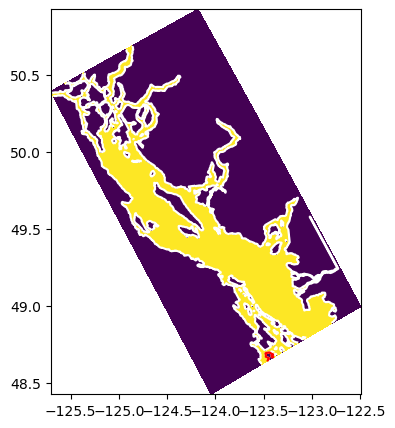

In [12]:
fig,ax=plt.subplots(1,1,figsize=(4,5))
ax.pcolormesh(navlon[350:850,100:398],navlat[350:850,100:398],tmask[0,350:850,100:398],shading='auto')
cl=ax.contour(navlon[350:850,100:398],navlat[350:850,100:398],tmask[0,350:850,100:398],[.5],colors='w')
plt.plot(cl.allsegs[0][0][:,0],cl.allsegs[0][0][:,1],'r-')

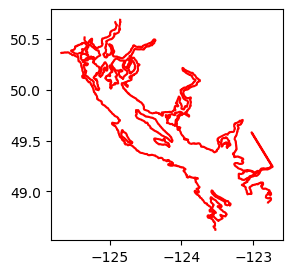

In [13]:
fig,ax=plt.subplots(1,1,figsize=(3,3))
lens=list()
modlines=list()
for ii in range(0,len(cl.allsegs[0])):
    lens.append(len(cl.allsegs[0][ii][:,1]))
    #if np.min(cl.allsegs[0][ii][:,1])<49.2 and np.max(cl.allsegs[0][ii][:,1])>50:
    if len(cl.allsegs[0][ii][:,1])>100:
        #print(ii)
        ax.plot(cl.allsegs[0][ii][:,0],cl.allsegs[0][ii][:,1],'r-')
        modlines.append((cl.allsegs[0][ii][:,0],cl.allsegs[0][ii][:,1]))

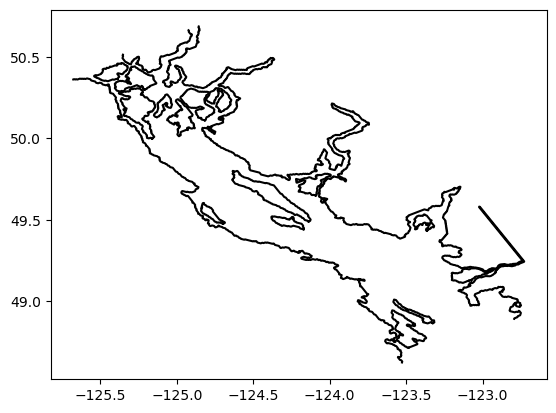

In [14]:
for (lons,lats) in modlines:
    plt.plot(lons,lats,'k-')

In [15]:
opslines=list()
for (lons,lats) in modlines:
    x=np.array([geo_tools.find_closest_model_point(lon,lat,ops_lon-360,ops_lat,grid='GEM2.5') \
                for lat, lon in zip(lats,lons)])
    opslines.append((x[:,0],x[:,1]))

In [16]:
gl1lines=list()
for (lons,lats) in modlines:
    x=np.array([geo_tools.find_closest_model_point(lon,lat,gl1_lon-360,gl1_lat,grid='GEM2.5') \
                for lat, lon in zip(lats,lons)])
    gl1lines.append((x[:,0],x[:,1]))

In [17]:
gl2lines=list()
for (lons,lats) in modlines:
    x=np.array([geo_tools.find_closest_model_point(lon,lat,gl2_lon-360,gl2_lat,grid='GEM2.5') \
                for lat, lon in zip(lats,lons)])
    gl2lines.append((x[:,0],x[:,1]))

In [18]:
conlines=list()
for (lons,lats) in modlines:
    x=np.array([geo_tools.find_closest_model_point(lon,lat,con_lon-360,con_lat,grid='continental2.5') \
                for lat, lon in zip(lats,lons)])
    conlines.append((x[:,0],x[:,1]))

In [19]:
import os
import glob
import pandas as pd

In [20]:
def _vertNetmatch(data,flist,ftypes,filemap_r,gridmask,e3t0,maskName='tmask'):
    """ basic vertical matching of model output to data
        returns model value from model grid cell that would contain the observation point with
        no interpolation; no consideration of the changing of grid thickenss with the tides (vvl)
        strategy: loop through data, openening and closing model files as needed and storing model data
    """
    if len(data)>5000:
        pprint=True
        lendat=len(data)
    else:
        pprint= False
    # set up columns to hold indices for upper and lower end of range to average over
    data['k_upper']=-1*np.ones((len(data))).astype(int)
    data['k_lower']=-1*np.ones((len(data))).astype(int)
    for ind, row in data.iterrows():
        if (pprint==True and ind%5000==0):
            print('progress: {}%'.format(ind/lendat*100))
        if ind==0: # special case for start of loop; load first files
            fid=dict()
            fend=dict()
            torig=dict()
            for ift in ftypes:
                fid,fend=_nextfile_bin(ift,row['dtUTC'],flist[ift],fid,fend,flist)
                # handle NEMO files time reference
                if 'time_centered' in fid[ftypes[0]].variables.keys():
                    torig[ift]=dt.datetime.strptime(fid[ftypes[0]].variables['time_centered'].time_origin,'%Y-%m-%d %H:%M:%S')
                else:
                    torig[ift]=dt.datetime.strptime(fid[ftypes[0]].variables['time_counter'].time_origin,'%Y-%m-%d %H:%M:%S')
        # loop through each file type to extract data from the appropriate time and location
        for ift in ftypes:
            if row['dtUTC']>=fend[ift]:
                fid,fend=_nextfile_bin(ift,row['dtUTC'],flist[ift],fid,fend,flist)
            # now read data
            # find time index
            try:
                if 'time_centered_bounds' in fid[ift].variables.keys(): # no problem! 
                    ih=_getTimeInd_bin(row['dtUTC'],fid[ift],torig[ift])
                else: # annoying!
                    hpf=(flist[ift]['t_n'][0]-flist[ift]['t_0'][0]).total_seconds()/3600 #hours per file
                    ih=_getTimeInd_bin(row['dtUTC'],fid[ift],torig[ift],hpf=hpf)
                    print(flist[ift]['t_n'])
            except:
                print(row['dtUTC'],ift,torig[ift])
                tlist=fid[ift].variables['time_centered_bounds'][:,:]
                for el in tlist:
                    print(el)
                print((row['dtUTC']-torig[ift]).total_seconds())
                print(tlist[-1,1])
                raise
            # find depth indices (assume they may be reversed)
            z_l=max(row['Z_upper'],row['Z_lower'])
            z_u=min(row['Z_upper'],row['Z_lower'])
            if len(set(fid[ift].variables.keys()).intersection(set(('deptht_bounds','depthu_bounds','depthv_bounds'))))>0: # no problem! 
                ik_l=_getZInd_bin(z_l,fid[ift],maskName=maskName)
                ik_u=_getZInd_bin(z_u,fid[ift],maskName=maskName)
            else: # workaround for missing variable
                ik_l=_getZInd_bin(z_l,fid[ift],boundsFlag=True,maskName=maskName)
                ik_u=_getZInd_bin(z_u,fid[ift],boundsFlag=True,maskName=maskName)
            # assign values for each var assoc with ift
            if (not np.isnan(ik_l)) and (not np.isnan(ik_u)) and \
                         (gridmask[0,ik_u,row['j'],row['i']]==1):
                data.loc[ind,['k_upper']]=int(ik_u)
                data.loc[ind,['k_lower']]=int(ik_l)
                for ivar in filemap_r[ift]:
                    var=fid[ift].variables[ivar][ih,ik_u:(ik_l+1),row['j'],row['i']]
                    e3t=e3t0[ik_u:(ik_l+1),row['j'],row['i']]
                    imask=gridmask[0,ik_u:(ik_l+1),row['j'],row['i']]
                    meanvar=np.sum(var*e3t*imask)/np.sum(e3t*imask)
                    data.loc[ind,['mod_'+ivar]]=meanvar
                    if gridmask[0,ik_l,row['j'],row['i']]==0:
                        print(f"Warning: lower limit is not an ocean value:",
                             f" i={row['i']}, j={row['j']}, k_upper={ik_u}, k_lower={ik_l},",
                             f"k_seafloor={np.sum(imask)}",
                             f"Lon={row['Lon']}, Lat={row['Lat']}, dtUTC={row['dtUTC']}")
            else:
                print(f"Warning: upper limit is not an ocean value:",
                     f" i={row['i']}, j={row['j']}, k_upper={ik_u},Lat={row['Lat']},",
                     f"Lon={row['Lon']},dtUTC={row['dtUTC']}")
    return data            

In [21]:
def index_model_files(start,end,basedir,nam_fmt,flen,ftype=None,tres=1):
    """
    See inputs for matchData above.
    outputs pandas dataframe containing columns 'paths','t_0', and 't_1'
    where paths are all the model output files of a given type in the time interval (start,end)
    with end not included
    """
    if ftype not in ('ptrc_T', 'grid_T', 'grid_W', 'grid_U', 'grid_V',
                     'dia1_T', 'carp_T', 'biol_T', 'chem_T', 'None', None):
        print('ftype={}, are you sure? (if yes, add to list)'.format(ftype))
    if tres==24:
        ftres='1d'
    else:
        ftres=str(int(tres))+'h'
    ffmt='%Y%m%d'
    dfmt='%d%b%y'
    wfmt='y%Ym%md%d'
    if nam_fmt=='nowcast':
        stencil='{0}/SalishSea_'+ftres+'_{1}_{2}_'+ftype+'.nc'
    elif nam_fmt=='long':
       stencil='**/SalishSea_'+ftres+'*'+ftype+'_{1}-{2}.nc'
    elif nam_fmt=='sockeye':
       stencil=f'*/SalishSea_{ftres}*{ftype}_{{1}}-{{2}}.nc'
    elif nam_fmt == 'optimum':
       stencil = f'???????/SalishSea_{ftres}*{ftype}_{{1}}-{{2}}.nc'
    elif nam_fmt=='wind':
       stencil='ops_{3}.nc'
    elif nam_fmt=='ops':
       stencil='ops_{3}.nc'
    elif nam_fmt=='gemlam':
       stencil='gemlam_{3}.nc'
    elif nam_fmt=='hrdps':
       stencil='hrdps_{3}.nc'
    elif nam_fmt=='forcing': # use ftype as prefix
       stencil=ftype+'_{3}.nc'
    else:
        raise Exception('nam_fmt '+nam_fmt+' is not defined')
    #Note fix: to avoid errors if hour and second included with start and end time, strip them!
    iits=dt.datetime(start.year,start.month,start.day)
    iite=iits+dt.timedelta(days=(flen-1))
    # check if start is a file start date and if not, try to identify the file including it
    # (in case start date is in the middle of a multi-day file)
    nday=0
    while True:
        try:
            ipathstr=os.path.join(basedir,stencil.format(iits.strftime(dfmt).lower(),
                    iits.strftime(ffmt),iite.strftime(ffmt),iits.strftime(wfmt)))
            iifstr=glob.glob(ipathstr,recursive=True)[0]
            if nday>0:
                print('first file starts on ',iits)
            break # file has been found
        except IndexError:
            nday=nday+1
            if nday==flen:
                iits_str=iits.strftime('%Y %b %d')
                start_str=start.strftime('%Y %b %d')
                if flen==1:
                    exc_msg= (f'\nFile not found:\n{ipathstr}\n'
                             f'Check that results directory is accessible and the start date entered is included in the run. \n')
                else:
                    exc_msg= (f'\nDays per output file is set to {flen}. \n'
                             f'No file found with start date in range {iits_str} to {start_str} \n'
                             f'of form {ipathstr}\n'
                             f'Check that results directory is accessible and the start date entered is included in run. \n')
                raise Exception(exc_msg) # file has not been found
            iits=start-dt.timedelta(days=nday)
            iite=iits+dt.timedelta(days=(flen-1))
    ind=0
    inds=list()
    paths=list()
    t_0=list()
    t_n=list()
    while iits<end:
        iite=iits+dt.timedelta(days=(flen-1))
        iitn=iits+dt.timedelta(days=flen)
        try:
            iifstr=glob.glob(os.path.join(basedir,stencil.format(iits.strftime(dfmt).lower(),
                    iits.strftime(ffmt),iite.strftime(ffmt),iits.strftime(wfmt))),recursive=True)[0]
        except IndexError:
            raise Exception('file does not exist:  '+os.path.join(basedir,stencil.format(iits.strftime(dfmt).lower(),
                iits.strftime(ffmt),iite.strftime(ffmt),iits.strftime(wfmt))))
        inds.append(ind)
        paths.append(iifstr)
        t_0.append(iits)
        t_n.append(iitn)
        iits=iitn
        ind=ind+1
    return pd.DataFrame(data=np.swapaxes([paths,t_0,t_n],0,1),index=inds,columns=['paths','t_0','t_n'])

In [22]:
# extract march mean wind from one of each type of file:
## ops, 2015
year=2015
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
U3ops=(fu**2+fv**2)**(1/2) ## use 3/2 to get wind speed cubed
U3opsmean=np.mean(U3ops,0)

## gl1, 2007
year=2007
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
U3gl1=(fu**2+fv**2)**(1/2)
U3gl1mean=np.mean(U3gl1,0)

## gl2, 2012
year=2012
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
U3gl2=(fu**2+fv**2)**(1/2)
U3gl2mean=np.mean(U3gl2,0)

## con, 2021

year=2023
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
U3con=(fu**2+fv**2)**(1/2)
U3conmean=np.mean(U3con,0)

## Test to make sure the land mask works

In [23]:
year=2008
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,2),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1]))for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
test=(fu**2+fv**2)**(1/2)
testmean=np.mean(test,0)

#
#.where(HRDPS.landmask)

In [24]:
test2008=np.nanmean(testmean)

In [25]:
fu.shape

(24, 33, 56)

In [26]:
fs[0]['u_wind'].shape

(24, 266, 256)

In [27]:
Watermask1.mask.shape

(266, 256)

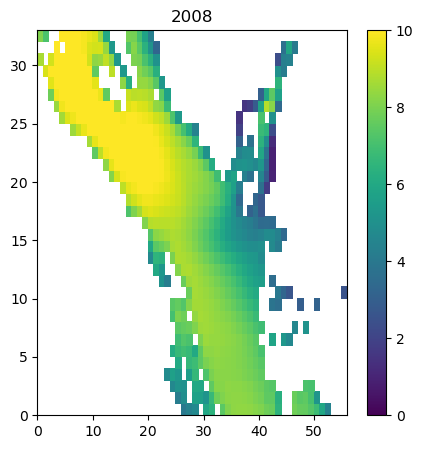

In [28]:
fig,ax=plt.subplots(1,1,figsize=(5,5))
vmin=0
vmax=10

iax=ax
iax.set_title('2008')
m=iax.pcolormesh(testmean,vmin=vmin, vmax=vmax)
fig.colorbar(m,ax=iax)
#for (jj,ii) in gl1lines:
#    iax.plot(ii-96,jj-114,'r-')

## January

In [29]:
# extract march mean wind from one of each type of file:

## gl1, 2007
#year=2007
#day=dt.datetime(year,1,1)
#opsdir, namfmt, jlims, ilims = getWindVars(day)
#flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
#                           flen=1,ftype='None',tres=24);
#fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
#fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
#fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
#gl12007=(fu**2+fv**2)**(3/2)
#margl12007mean=np.mean(gl12007,0)

## gl1, 2008
year=2008
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl12008=(fu**2+fv**2)**(1/2)
jan_gl12008mean=np.mean(jan_gl12008,0)

## gl1, 2007
year=2009
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl12009=(fu**2+fv**2)**(1/2)
jan_gl12009mean=np.mean(jan_gl12009,0)

## gl1, 2007
year=2010
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl12010=(fu**2+fv**2)**(1/2)
jan_gl12010mean=np.mean(jan_gl12010,0)

## gl1, 2007
year=2011
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl12011=(fu**2+fv**2)**(1/2)
jan_gl12011mean=np.mean(jan_gl12011,0)

## gl1, 2007
year=2012
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl22012=(fu**2+fv**2)**(1/2)
jan_gl22012mean=np.mean(jan_gl22012,0)

## gl1, 2007
year=2013
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl22013=(fu**2+fv**2)**(1/2)
jan_gl22013mean=np.mean(jan_gl22013,0)

## gl1, 2007
year=2014
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_gl22014=(fu**2+fv**2)**(1/2)
jan_gl22014mean=np.mean(jan_gl22014,0)

## gl1, 2007
year=2015
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2015=(fu**2+fv**2)**(1/2)
jan_ops2015mean=np.mean(jan_ops2015,0)

## ops, 2015
year=2016
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2016=(fu**2+fv**2)**(1/2)
jan_ops2016mean=np.mean(jan_ops2016,0)

## gl1, 2007
year=2017
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2017=(fu**2+fv**2)**(1/2)
jan_ops2017mean=np.mean(jan_ops2017,0)

## gl1, 2007
year=2018
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2018=(fu**2+fv**2)**(1/2)
jan_ops2018mean=np.mean(jan_ops2018,0)

## gl1, 2007
year=2019
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2019=(fu**2+fv**2)**(1/2)
jan_ops2019mean=np.mean(jan_ops2019,0)

## gl1, 2007
year=2020
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2020=(fu**2+fv**2)**(1/2)
jan_ops2020mean=np.mean(jan_ops2020,0)

year=2021
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2021=(fu**2+fv**2)**(1/2)
jan_ops2021mean=np.mean(jan_ops2021,0)


year=2022
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_ops2022=(fu**2+fv**2)**(1/2)
jan_ops2022mean=np.mean(jan_ops2022,0)

year=2023
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,23),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_con2023=(fu**2+fv**2)**(1/2)
jan_con2023mean=np.mean(jan_con2023,0)

year=2024
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_con2024=(fu**2+fv**2)**(1/2)
jan_con2024mean=np.mean(jan_con2024,0)

year=2025
day=dt.datetime(year,1,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,1,1),dt.datetime(year,1,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jan_con2025=(fu**2+fv**2)**(1/2)
jan_con2025mean=np.mean(jan_con2025,0)

In [30]:
jan_ops2020mean

<xarray.DataArray (y: 33, x: 49)>
dask.array<mean_agg-aggregate, shape=(33, 49), dtype=float32, chunksize=(33, 49), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 2.775e+05 2.8e+05 2.825e+05 ... 3.95e+05 3.975e+05
  * y        (y) float64 3.25e+05 3.275e+05 3.3e+05 ... 4e+05 4.025e+05 4.05e+05

In [31]:
#Jan2007=np.nanmean(jan_gl12007mean)
Jan2008=np.nanmean(jan_gl12008mean)
Jan2009=np.nanmean(jan_gl12009mean)
Jan2010=np.nanmean(jan_gl12010mean)
Jan2011=np.nanmean(jan_gl12011mean)
Jan2012=np.nanmean(jan_gl22012mean)
Jan2013=np.nanmean(jan_gl22013mean)
Jan2014=np.nanmean(jan_gl22014mean)
Jan2015=np.nanmean(jan_ops2015mean)
Jan2016=np.nanmean(jan_ops2016mean)
Jan2017=np.nanmean(jan_ops2017mean)
Jan2018=np.nanmean(jan_ops2018mean)
Jan2019=np.nanmean(jan_ops2019mean)
Jan2020=np.nanmean(jan_ops2020mean)
Jan2021=np.nanmean(jan_ops2021mean)
Jan2022=np.nanmean(jan_ops2022mean)
Jan2023=np.nanmean(jan_con2023mean)
Jan2024=np.nanmean(jan_con2024mean)
Jan2025=np.nanmean(jan_con2025mean)

In [32]:
print(Jan2008,Jan2009,Jan2010,Jan2011,Jan2012,Jan2013,Jan2014,Jan2015,Jan2016,
      Jan2017,Jan2018,Jan2019,Jan2020,Jan2021,Jan2022,Jan2023,Jan2024)

5.551758 4.3664002 5.718831 4.7378073 6.0040736 3.7714164 3.887359 3.6110241 4.664751 4.6162724 5.287108 4.687394 6.949731 5.3775268 4.3367558 5.180191 4.896854225224756


## February

In [33]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl12007=(fu**2+fv**2)**(1/2)
feb_gl12007mean=np.mean(feb_gl12007,0)


year=2008
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,29),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl12008=(fu**2+fv**2)**(1/2)
feb_gl12008mean=np.mean(feb_gl12008,0)


year=2009
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl12009=(fu**2+fv**2)**(1/2)
feb_gl12009mean=np.mean(feb_gl12009,0)


year=2010
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl12010=(fu**2+fv**2)**(1/2)
feb_gl12010mean=np.mean(feb_gl12010,0)


year=2011
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl12011=(fu**2+fv**2)**(1/2)
feb_gl12011mean=np.mean(feb_gl12011,0)


year=2012
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,29),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl22012=(fu**2+fv**2)**(1/2)
feb_gl22012mean=np.mean(feb_gl22012,0)


year=2013
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl22013=(fu**2+fv**2)**(1/2)
feb_gl22013mean=np.mean(feb_gl22013,0)


year=2014
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_gl22014=(fu**2+fv**2)**(1/2)
feb_gl22014mean=np.mean(feb_gl22014,0)


year=2015
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2015=(fu**2+fv**2)**(1/2)
feb_ops2015mean=np.mean(feb_ops2015,0)


year=2016
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,29),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2016=(fu**2+fv**2)**(1/2)
feb_ops2016mean=np.mean(feb_ops2016,0)


year=2017
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2017=(fu**2+fv**2)**(1/2)
feb_ops2017mean=np.mean(feb_ops2017,0)


year=2018
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2018=(fu**2+fv**2)**(1/2)
feb_ops2018mean=np.mean(feb_ops2018,0)


year=2019
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2019=(fu**2+fv**2)**(1/2)
feb_ops2019mean=np.mean(feb_ops2019,0)


year=2020
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,29),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2020=(fu**2+fv**2)**(1/2)
feb_ops2020mean=np.mean(feb_ops2020,0)

year=2021
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2021=(fu**2+fv**2)**(1/2)
feb_ops2021mean=np.mean(feb_ops2021,0)

year=2022
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_ops2022=(fu**2+fv**2)**(1/2)
feb_ops2022mean=np.mean(feb_ops2022,0)

year=2023
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,22),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_con2023=(fu**2+fv**2)**(1/2)
feb_con2023mean=np.mean(feb_con2023,0)

year=2024
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_con2024=(fu**2+fv**2)**(1/2)
feb_con2024mean=np.mean(feb_con2024,0)

year=2025
day=dt.datetime(year,2,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,2,1),dt.datetime(year,2,28),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
feb_con2025=(fu**2+fv**2)**(1/2)
feb_con2025mean=np.mean(feb_con2025,0)

In [34]:
Feb2007=np.nanmean(feb_gl12007mean)
Feb2008=np.nanmean(feb_gl12008mean)
Feb2009=np.nanmean(feb_gl12009mean)
Feb2010=np.nanmean(feb_gl12010mean)
Feb2011=np.nanmean(feb_gl12011mean)
Feb2012=np.nanmean(feb_gl22012mean)
Feb2013=np.nanmean(feb_gl22013mean)
Feb2014=np.nanmean(feb_gl22014mean)
Feb2015=np.nanmean(feb_ops2015mean)
Feb2016=np.nanmean(feb_ops2016mean)
Feb2017=np.nanmean(feb_ops2017mean)
Feb2018=np.nanmean(feb_ops2018mean)
Feb2019=np.nanmean(feb_ops2019mean)
Feb2020=np.nanmean(feb_ops2020mean)
Feb2021=np.nanmean(feb_ops2021mean)
Feb2022=np.nanmean(feb_ops2022mean)
Feb2023=np.nanmean(feb_con2023mean)
Feb2024=np.nanmean(feb_con2024mean)
Feb2025=np.nanmean(feb_con2025mean)

In [35]:
print(Feb2007,Feb2008,Feb2009,Feb2010,Feb2011,Feb2012,Feb2013,Feb2014,Feb2015,Feb2016,
      Feb2017,Feb2018,Feb2019,Feb2020,Feb2021,Feb2022,Feb2023,Feb2024,Feb2025)

4.87161 4.4020443 4.1070614 4.83691 5.5196977 5.455469 4.6428947 4.8739166 3.792426 4.2877007 4.4788394 4.007738 4.619625 4.318642 5.719812 3.637045 4.857997 3.8777867453156367 4.421670843808195


## March

In [36]:
# extract march mean wind from one of each type of file:

## gl1, 2007
year=2007
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl12007=(fu**2+fv**2)**(1/2)
mar_gl12007mean=np.mean(mar_gl12007,0)

## gl1, 2008
year=2008
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl12008=(fu**2+fv**2)**(1/2)
mar_gl12008mean=np.mean(mar_gl12008,0)

## gl1, 2007
year=2009
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl12009=(fu**2+fv**2)**(1/2)
mar_gl12009mean=np.mean(mar_gl12009,0)

## gl1, 2007
year=2010
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl12010=(fu**2+fv**2)**(1/2)
mar_gl12010mean=np.mean(mar_gl12010,0)

## gl1, 2007
year=2011
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl12011=(fu**2+fv**2)**(1/2)
mar_gl12011mean=np.mean(mar_gl12011,0)

## gl1, 2007
year=2012
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl22012=(fu**2+fv**2)**(1/2)
mar_gl22012mean=np.mean(mar_gl22012,0)

## gl1, 2007
year=2013
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl22013=(fu**2+fv**2)**(1/2)
mar_gl22013mean=np.mean(mar_gl22013,0)

## gl1, 2007
year=2014
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_gl22014=(fu**2+fv**2)**(1/2)
mar_gl22014mean=np.mean(mar_gl22014,0)

## gl1, 2007
year=2015
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2015=(fu**2+fv**2)**(1/2)
mar_ops2015mean=np.mean(mar_ops2015,0)

## ops, 2015
year=2016
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2016=(fu**2+fv**2)**(1/2)
mar_ops2016mean=np.mean(mar_ops2016,0)

## gl1, 2007
year=2017
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2017=(fu**2+fv**2)**(1/2)
mar_ops2017mean=np.mean(mar_ops2017,0)

## gl1, 2007
year=2018
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2018=(fu**2+fv**2)**(1/2)
mar_ops2018mean=np.mean(mar_ops2018,0)

## gl1, 2007
year=2019
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2019=(fu**2+fv**2)**(1/2)
mar_ops2019mean=np.mean(mar_ops2019,0)

## gl1, 2007
year=2020
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2020=(fu**2+fv**2)**(1/2)
mar_ops2020mean=np.mean(mar_ops2020,0)


year=2021
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2021=(fu**2+fv**2)**(1/2)
mar_ops2021mean=np.mean(mar_ops2021,0)


year=2022
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_ops2022=(fu**2+fv**2)**(1/2)
mar_ops2022mean=np.mean(mar_ops2022,0)

#### Switch from et.index_model_files to just index_model_files (defined above) because of the new file type
year=2023
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_con2023=(fu**2+fv**2)**(1/2)
mar_con2023mean=np.mean(mar_con2023,0)

year=2024
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_con2024=(fu**2+fv**2)**(1/2)
mar_con2024mean=np.mean(mar_con2024,0)

year=2025
day=dt.datetime(year,3,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,3,1),dt.datetime(year,3,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
mar_con2025=(fu**2+fv**2)**(1/2)
mar_con2025mean=np.mean(mar_con2025,0)


In [37]:
Mar2007=np.nanmean(mar_gl12007mean)
Mar2008=np.nanmean(mar_gl12008mean)
Mar2009=np.nanmean(mar_gl12009mean)
Mar2010=np.nanmean(mar_gl12010mean)
Mar2011=np.nanmean(mar_gl12011mean)
Mar2012=np.nanmean(mar_gl22012mean)
Mar2013=np.nanmean(mar_gl22013mean)
Mar2014=np.nanmean(mar_gl22014mean)
Mar2015=np.nanmean(mar_ops2015mean)
Mar2016=np.nanmean(mar_ops2016mean)
Mar2017=np.nanmean(mar_ops2017mean)
Mar2018=np.nanmean(mar_ops2018mean)
Mar2019=np.nanmean(mar_ops2019mean)
Mar2020=np.nanmean(mar_ops2020mean)
Mar2021=np.nanmean(mar_ops2021mean)
Mar2022=np.nanmean(mar_ops2022mean)
Mar2023=np.nanmean(mar_con2023mean)
Mar2024=np.nanmean(mar_con2024mean)
Mar2025=np.nanmean(mar_con2025mean)

In [38]:
print(Mar2007,Mar2008,Mar2009,Mar2010,Mar2011,Mar2012,Mar2013,Mar2014,Mar2015,Mar2016,
      Mar2017,Mar2018,Mar2019,Mar2020,Mar2021,Mar2022,Mar2023,Mar2024,Mar2025)

5.6584525 5.1153183 5.5833764 4.9662023 5.8553214 6.250565 4.589107 5.046934 3.972365 5.533703 5.035003 3.4580605 3.2797759 4.354045 5.116473 4.15275 3.8851525412075807 4.427344322862073 4.930886065143937


## April

In [39]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl12007=(fu**2+fv**2)**(1/2)
apr_gl12007mean=np.mean(apr_gl12007,0)


year=2008
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl12008=(fu**2+fv**2)**(1/2)
apr_gl12008mean=np.mean(apr_gl12008,0)


year=2009
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl12009=(fu**2+fv**2)**(1/2)
apr_gl12009mean=np.mean(apr_gl12009,0)


year=2010
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl12010=(fu**2+fv**2)**(1/2)
apr_gl12010mean=np.mean(apr_gl12010,0)


year=2011
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl12011=(fu**2+fv**2)**(1/2)
apr_gl12011mean=np.mean(apr_gl12011,0)


year=2012
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl22012=(fu**2+fv**2)**(1/2)
apr_gl22012mean=np.mean(apr_gl22012,0)


year=2013
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl22013=(fu**2+fv**2)**(1/2)
apr_gl22013mean=np.mean(apr_gl22013,0)


year=2014
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_gl22014=(fu**2+fv**2)**(1/2)
apr_gl22014mean=np.mean(apr_gl22014,0)


year=2015
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2015=(fu**2+fv**2)**(1/2)
apr_ops2015mean=np.mean(apr_ops2015,0)


year=2016
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2016=(fu**2+fv**2)**(1/2)
apr_ops2016mean=np.mean(apr_ops2016,0)


year=2017
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2017=(fu**2+fv**2)**(1/2)
apr_ops2017mean=np.mean(apr_ops2017,0)


year=2018
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2018=(fu**2+fv**2)**(1/2)
apr_ops2018mean=np.mean(apr_ops2018,0)


year=2019
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2019=(fu**2+fv**2)**(1/2)
apr_ops2019mean=np.mean(apr_ops2019,0)


year=2020
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2020=(fu**2+fv**2)**(1/2)
apr_ops2020mean=np.mean(apr_ops2020,0)

year=2021
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2021=(fu**2+fv**2)**(1/2)
apr_ops2021mean=np.mean(apr_ops2021,0)

year=2022
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_ops2022=(fu**2+fv**2)**(1/2)
apr_ops2022mean=np.mean(apr_ops2022,0)

year=2023
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_con2023=(fu**2+fv**2)**(1/2)
apr_con2023mean=np.mean(apr_con2023,0)


year=2024
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_con2024=(fu**2+fv**2)**(1/2)
apr_con2024mean=np.mean(apr_con2024,0)

year=2025
day=dt.datetime(year,4,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,4,1),dt.datetime(year,4,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
apr_con2025=(fu**2+fv**2)**(1/2)
apr_con2025mean=np.mean(apr_con2025,0)

In [40]:
Apr2007=np.nanmean(apr_gl12007mean)
Apr2008=np.nanmean(apr_gl12008mean)
Apr2009=np.nanmean(apr_gl12009mean)
Apr2010=np.nanmean(apr_gl12010mean)
Apr2011=np.nanmean(apr_gl12011mean)
Apr2012=np.nanmean(apr_gl22012mean)
Apr2013=np.nanmean(apr_gl22013mean)
Apr2014=np.nanmean(apr_gl22014mean)
Apr2015=np.nanmean(apr_ops2015mean)
Apr2016=np.nanmean(apr_ops2016mean)
Apr2017=np.nanmean(apr_ops2017mean)
Apr2018=np.nanmean(apr_ops2018mean)
Apr2019=np.nanmean(apr_ops2019mean)
Apr2020=np.nanmean(apr_ops2020mean)
Apr2021=np.nanmean(apr_ops2021mean)
Apr2022=np.nanmean(apr_ops2022mean)
Apr2023=np.nanmean(apr_con2023mean)
Apr2024=np.nanmean(apr_con2024mean)
Apr2025=np.nanmean(apr_con2025mean)

In [42]:
print(Apr2007,Apr2008,Apr2009,Apr2010,Apr2011,Apr2012,Apr2013,Apr2014,Apr2015,Apr2016,
      Apr2017,Apr2018,Apr2019,Apr2020,Apr2021,Apr2022,Apr2023,Apr2024,Apr2025)

4.320769 4.0749683 4.76013 5.582724 4.9674006 4.173969 4.7208796 4.586836 4.469233 4.0199237 4.4105606 4.2903333 5.0487456 3.884972 4.0471873 4.255461 4.93082378244007 4.427716536682861 4.361871133440438


## May

In [43]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl12007=(fu**2+fv**2)**(1/2)
may_gl12007mean=np.mean(may_gl12007,0)


year=2008
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl12008=(fu**2+fv**2)**(1/2)
may_gl12008mean=np.mean(may_gl12008,0)


year=2009
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl12009=(fu**2+fv**2)**(1/2)
may_gl12009mean=np.mean(may_gl12009,0)


year=2010
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl12010=(fu**2+fv**2)**(1/2)
may_gl12010mean=np.mean(may_gl12010,0)


year=2011
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl12011=(fu**2+fv**2)**(1/2)
may_gl12011mean=np.mean(may_gl12011,0)


year=2012
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl22012=(fu**2+fv**2)**(1/2)
may_gl22012mean=np.mean(may_gl22012,0)


year=2013
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl22013=(fu**2+fv**2)**(1/2)
may_gl22013mean=np.mean(may_gl22013,0)


year=2014
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_gl22014=(fu**2+fv**2)**(1/2)
may_gl22014mean=np.mean(may_gl22014,0)


year=2015
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2015=(fu**2+fv**2)**(1/2)
may_ops2015mean=np.mean(may_ops2015,0)


year=2016
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2016=(fu**2+fv**2)**(1/2)
may_ops2016mean=np.mean(may_ops2016,0)


year=2017
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2017=(fu**2+fv**2)**(1/2)
may_ops2017mean=np.mean(may_ops2017,0)


year=2018
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2018=(fu**2+fv**2)**(1/2)
may_ops2018mean=np.mean(may_ops2018,0)


year=2019
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2019=(fu**2+fv**2)**(1/2)
may_ops2019mean=np.mean(may_ops2019,0)


year=2020
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2020=(fu**2+fv**2)**(1/2)
may_ops2020mean=np.mean(may_ops2020,0)

year=2021
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2021=(fu**2+fv**2)**(1/2)
may_ops2021mean=np.mean(may_ops2021,0)

year=2022
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_ops2022=(fu**2+fv**2)**(1/2)
may_ops2022mean=np.mean(may_ops2022,0)

year=2023
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_con2023=(fu**2+fv**2)**(1/2)
may_con2023mean=np.mean(may_con2023,0)

year=2024
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_con2024=(fu**2+fv**2)**(1/2)
may_con2024mean=np.mean(may_con2024,0)

year=2025
day=dt.datetime(year,5,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,5,1),dt.datetime(year,5,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
may_con2025=(fu**2+fv**2)**(1/2)
may_con2025mean=np.mean(may_con2025,0)

In [44]:
May2007=np.nanmean(may_gl12007mean)
May2008=np.nanmean(may_gl12008mean)
May2009=np.nanmean(may_gl12009mean)
May2010=np.nanmean(may_gl12010mean)
May2011=np.nanmean(may_gl12011mean)
May2012=np.nanmean(may_gl22012mean)
May2013=np.nanmean(may_gl22013mean)
May2014=np.nanmean(may_gl22014mean)
May2015=np.nanmean(may_ops2015mean)
May2016=np.nanmean(may_ops2016mean)
May2017=np.nanmean(may_ops2017mean)
May2018=np.nanmean(may_ops2018mean)
May2019=np.nanmean(may_ops2019mean)
May2020=np.nanmean(may_ops2020mean)
May2021=np.nanmean(may_ops2021mean)
May2022=np.nanmean(may_ops2022mean)
May2023=np.nanmean(may_con2023mean)
May2024=np.nanmean(may_con2024mean)
May2025=np.nanmean(may_con2025mean)

In [45]:
print(May2007,May2008,May2009,May2010,May2011,May2012,May2013,May2014,May2015,May2016,
      May2017,May2018,May2019,May2020,May2021,May2022,May2023,May2024,May2025)

4.1462255 4.484904 4.46116 4.2599277 3.9618323 4.569358 3.7445831 3.6786942 3.4472172 4.4066916 3.2961855 3.108354 3.9454465 3.7006972 3.8645449 3.89645 3.0254895047764174 4.495906115308329 3.483618857810216


## June

In [46]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl12007=(fu**2+fv**2)**(1/2)
jun_gl12007mean=np.mean(jun_gl12007,0)


year=2008
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl12008=(fu**2+fv**2)**(1/2)
jun_gl12008mean=np.mean(jun_gl12008,0)


year=2009
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl12009=(fu**2+fv**2)**(1/2)
jun_gl12009mean=np.mean(jun_gl12009,0)


year=2010
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl12010=(fu**2+fv**2)**(1/2)
jun_gl12010mean=np.mean(jun_gl12010,0)


year=2011
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl12011=(fu**2+fv**2)**(1/2)
jun_gl12011mean=np.mean(jun_gl12011,0)


year=2012
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl22012=(fu**2+fv**2)**(1/2)
jun_gl22012mean=np.mean(jun_gl22012,0)


year=2013
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl22013=(fu**2+fv**2)**(1/2)
jun_gl22013mean=np.mean(jun_gl22013,0)


year=2014
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_gl22014=(fu**2+fv**2)**(1/2)
jun_gl22014mean=np.mean(jun_gl22014,0)


year=2015
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2015=(fu**2+fv**2)**(1/2)
jun_ops2015mean=np.mean(jun_ops2015,0)


year=2016
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2016=(fu**2+fv**2)**(1/2)
jun_ops2016mean=np.mean(jun_ops2016,0)


year=2017
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2017=(fu**2+fv**2)**(1/2)
jun_ops2017mean=np.mean(jun_ops2017,0)


year=2018
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2018=(fu**2+fv**2)**(1/2)
jun_ops2018mean=np.mean(jun_ops2018,0)


year=2019
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2019=(fu**2+fv**2)**(1/2)
jun_ops2019mean=np.mean(jun_ops2019,0)


year=2020
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2020=(fu**2+fv**2)**(1/2)
jun_ops2020mean=np.mean(jun_ops2020,0)

year=2021
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2021=(fu**2+fv**2)**(1/2)
jun_ops2021mean=np.mean(jun_ops2021,0)

year=2022
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_ops2022=(fu**2+fv**2)**(1/2)
jun_ops2022mean=np.mean(jun_ops2022,0)

year=2023
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_con2023=(fu**2+fv**2)**(1/2)
jun_con2023mean=np.mean(jun_con2023,0)

year=2024
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_con2024=(fu**2+fv**2)**(1/2)
jun_con2024mean=np.mean(jun_con2024,0)

year=2025
day=dt.datetime(year,6,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,6,1),dt.datetime(year,6,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jun_con2025=(fu**2+fv**2)**(1/2)
jun_con2025mean=np.mean(jun_con2025,0)

In [47]:
Jun2007=np.nanmean(jun_gl12007mean)
Jun2008=np.nanmean(jun_gl12008mean)
Jun2009=np.nanmean(jun_gl12009mean)
Jun2010=np.nanmean(jun_gl12010mean)
Jun2011=np.nanmean(jun_gl12011mean)
Jun2012=np.nanmean(jun_gl22012mean)
Jun2013=np.nanmean(jun_gl22013mean)
Jun2014=np.nanmean(jun_gl22014mean)
Jun2015=np.nanmean(jun_ops2015mean)
Jun2016=np.nanmean(jun_ops2016mean)
Jun2017=np.nanmean(jun_ops2017mean)
Jun2018=np.nanmean(jun_ops2018mean)
Jun2019=np.nanmean(jun_ops2019mean)
Jun2020=np.nanmean(jun_ops2020mean)
Jun2021=np.nanmean(jun_ops2021mean)
Jun2022=np.nanmean(jun_ops2022mean)
Jun2023=np.nanmean(jun_con2023mean)
Jun2024=np.nanmean(jun_con2024mean)
Jun2025=np.nanmean(jun_con2025mean)

In [48]:
print(Jun2007,Jun2008,Jun2009,Jun2010,Jun2011,Jun2012,Jun2013,Jun2014,Jun2015,Jun2016,
      Jun2017,Jun2018,Jun2019,Jun2020,Jun2021,Jun2022,
      Jun2023,Jun2024,Jun2025)

3.8028028 4.2859936 4.159056 4.0049295 4.057323 4.293967 3.8779066 4.523662 4.7630424 3.8056262 3.7580824 3.671414 3.8355358 3.886506 4.0947633 3.729998 4.024886188960603 3.8329116068724525 4.111490503193382


## July

In [49]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl12007=(fu**2+fv**2)**(1/2)
jul_gl12007mean=np.mean(jul_gl12007,0)


year=2008
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl12008=(fu**2+fv**2)**(1/2)
jul_gl12008mean=np.mean(jul_gl12008,0)


year=2009
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl12009=(fu**2+fv**2)**(1/2)
jul_gl12009mean=np.mean(jul_gl12009,0)


year=2010
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl12010=(fu**2+fv**2)**(1/2)
jul_gl12010mean=np.mean(jul_gl12010,0)


year=2011
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl12011=(fu**2+fv**2)**(1/2)
jul_gl12011mean=np.mean(jul_gl12011,0)


year=2012
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl22012=(fu**2+fv**2)**(1/2)
jul_gl22012mean=np.mean(jul_gl22012,0)


year=2013
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl22013=(fu**2+fv**2)**(1/2)
jul_gl22013mean=np.mean(jul_gl22013,0)


year=2014
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_gl22014=(fu**2+fv**2)**(1/2)
jul_gl22014mean=np.mean(jul_gl22014,0)


year=2015
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2015=(fu**2+fv**2)**(1/2)
jul_ops2015mean=np.mean(jul_ops2015,0)


year=2016
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2016=(fu**2+fv**2)**(1/2)
jul_ops2016mean=np.mean(jul_ops2016,0)


year=2017
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2017=(fu**2+fv**2)**(1/2)
jul_ops2017mean=np.mean(jul_ops2017,0)


year=2018
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2018=(fu**2+fv**2)**(1/2)
jul_ops2018mean=np.mean(jul_ops2018,0)


year=2019
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2019=(fu**2+fv**2)**(1/2)
jul_ops2019mean=np.mean(jul_ops2019,0)


year=2020
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2020=(fu**2+fv**2)**(1/2)
jul_ops2020mean=np.mean(jul_ops2020,0)

year=2021
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2021=(fu**2+fv**2)**(1/2)
jul_ops2021mean=np.mean(jul_ops2021,0)

year=2022
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_ops2022=(fu**2+fv**2)**(1/2)
jul_ops2022mean=np.mean(jul_ops2022,0)

year=2023
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_con2023=(fu**2+fv**2)**(1/2)
jul_con2023mean=np.mean(jul_con2023,0)


year=2024
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_con2024=(fu**2+fv**2)**(1/2)
jul_con2024mean=np.mean(jul_con2024,0)

year=2025
day=dt.datetime(year,7,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,7,1),dt.datetime(year,7,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
jul_con2025=(fu**2+fv**2)**(1/2)
jul_con2025mean=np.mean(jul_con2025,0)

In [50]:
Jul2007=np.nanmean(jul_gl12007mean)
Jul2008=np.nanmean(jul_gl12008mean)
Jul2009=np.nanmean(jul_gl12009mean)
Jul2010=np.nanmean(jul_gl12010mean)
Jul2011=np.nanmean(jul_gl12011mean)
Jul2012=np.nanmean(jul_gl22012mean)
Jul2013=np.nanmean(jul_gl22013mean)
Jul2014=np.nanmean(jul_gl22014mean)
Jul2015=np.nanmean(jul_ops2015mean)
Jul2016=np.nanmean(jul_ops2016mean)
Jul2017=np.nanmean(jul_ops2017mean)
Jul2018=np.nanmean(jul_ops2018mean)
Jul2019=np.nanmean(jul_ops2019mean)
Jul2020=np.nanmean(jul_ops2020mean)
Jul2021=np.nanmean(jul_ops2021mean)
Jul2022=np.nanmean(jul_ops2022mean)
Jul2023=np.nanmean(jul_con2023mean)
Jul2024=np.nanmean(jul_con2024mean)
Jul2025=np.nanmean(jul_con2025mean)

In [51]:
print(Jul2007,Jul2008,Jul2009,Jul2010,Jul2011,Jul2012,Jul2013,Jul2014,Jul2015,Jul2016,
      Jul2017,Jul2018,Jul2019,Jul2020,Jul2021,Jul2022,Jul2023,Jul2024,Jul2025)

4.287942 4.6352673 4.2940583 4.887673 3.7261224 3.7577336 4.779974 3.930944 4.448506 4.2953115 3.3476176 3.7116055 3.2842255 3.786329 3.2678566 3.004751 3.651414100979097 3.7704109366122514 3.381776724468946


## August

In [52]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl12007=(fu**2+fv**2)**(1/2)
aug_gl12007mean=np.mean(aug_gl12007,0)


year=2008
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl12008=(fu**2+fv**2)**(1/2)
aug_gl12008mean=np.mean(aug_gl12008,0)


year=2009
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl12009=(fu**2+fv**2)**(1/2)
aug_gl12009mean=np.mean(aug_gl12009,0)


year=2010
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl12010=(fu**2+fv**2)**(1/2)
aug_gl12010mean=np.mean(aug_gl12010,0)


year=2011
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl12011=(fu**2+fv**2)**(1/2)
aug_gl12011mean=np.mean(aug_gl12011,0)


year=2012
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl22012=(fu**2+fv**2)**(1/2)
aug_gl22012mean=np.mean(aug_gl22012,0)


year=2013
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl22013=(fu**2+fv**2)**(1/2)
aug_gl22013mean=np.mean(aug_gl22013,0)


year=2014
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_gl22014=(fu**2+fv**2)**(1/2)
aug_gl22014mean=np.mean(aug_gl22014,0)


year=2015
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2015=(fu**2+fv**2)**(1/2)
aug_ops2015mean=np.mean(aug_ops2015,0)


year=2016
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2016=(fu**2+fv**2)**(1/2)
aug_ops2016mean=np.mean(aug_ops2016,0)


year=2017
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2017=(fu**2+fv**2)**(1/2)
aug_ops2017mean=np.mean(aug_ops2017,0)


year=2018
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2018=(fu**2+fv**2)**(1/2)
aug_ops2018mean=np.mean(aug_ops2018,0)


year=2019
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2019=(fu**2+fv**2)**(1/2)
aug_ops2019mean=np.mean(aug_ops2019,0)


year=2020
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2020=(fu**2+fv**2)**(1/2)
aug_ops2020mean=np.mean(aug_ops2020,0)

year=2021
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2021=(fu**2+fv**2)**(1/2)
aug_ops2021mean=np.mean(aug_ops2021,0)

year=2022
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2022=(fu**2+fv**2)**(1/2)
aug_ops2022mean=np.mean(aug_ops2022,0)

year=2023
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2023=(fu**2+fv**2)**(1/2)
aug_ops2023mean=np.mean(aug_ops2023,0)

year=2024
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2024=(fu**2+fv**2)**(1/2)
aug_ops2024mean=np.mean(aug_ops2024,0)

year=2025
day=dt.datetime(year,8,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,8,1),dt.datetime(year,8,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
aug_ops2025=(fu**2+fv**2)**(1/2)
aug_ops2025mean=np.mean(aug_ops2025,0)

In [53]:
Aug2007=np.nanmean(aug_gl12007mean)
Aug2008=np.nanmean(aug_gl12008mean)
Aug2009=np.nanmean(aug_gl12009mean)
Aug2010=np.nanmean(aug_gl12010mean)
Aug2011=np.nanmean(aug_gl12011mean)
Aug2012=np.nanmean(aug_gl22012mean)
Aug2013=np.nanmean(aug_gl22013mean)
Aug2014=np.nanmean(aug_gl22014mean)
Aug2015=np.nanmean(aug_ops2015mean)
Aug2016=np.nanmean(aug_ops2016mean)
Aug2017=np.nanmean(aug_ops2017mean)
Aug2018=np.nanmean(aug_ops2018mean)
Aug2019=np.nanmean(aug_ops2019mean)
Aug2020=np.nanmean(aug_ops2020mean)
Aug2021=np.nanmean(aug_ops2021mean)
Aug2022=np.nanmean(aug_ops2022mean)
Aug2023=np.nanmean(aug_ops2023mean)
Aug2024=np.nanmean(aug_ops2024mean)
Aug2025=np.nanmean(aug_ops2025mean)

In [54]:
print(Aug2007, Aug2008, Aug2009, Aug2010, Aug2011, Aug2012, Aug2013, Aug2014, Aug2015, Aug2016, 
      Aug2017, Aug2018, Aug2019, Aug2020, Aug2021, Aug2022,Aug2023,Aug2024,Aug2025)

3.8806083 4.5921745 3.880675 3.7800024 3.9913366 4.2186337 3.7981813 3.9285576 4.4147067 4.7240305 3.2837436 3.0639746 3.7253296 4.1147914 3.9817445 3.490351 3.975427344899359 3.3552802464171414 3.93553945954969


## September

In [55]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl12007=(fu**2+fv**2)**(1/2)
sep_gl12007mean=np.mean(sep_gl12007,0)


year=2008
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl12008=(fu**2+fv**2)**(1/2)
sep_gl12008mean=np.mean(sep_gl12008,0)


year=2009
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl12009=(fu**2+fv**2)**(1/2)
sep_gl12009mean=np.mean(sep_gl12009,0)


year=2010
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl12010=(fu**2+fv**2)**(1/2)
sep_gl12010mean=np.mean(sep_gl12010,0)


year=2011
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl12011=(fu**2+fv**2)**(1/2)
sep_gl12011mean=np.mean(sep_gl12011,0)


year=2012
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl22012=(fu**2+fv**2)**(1/2)
sep_gl22012mean=np.mean(sep_gl22012,0)


year=2013
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl22013=(fu**2+fv**2)**(1/2)
sep_gl22013mean=np.mean(sep_gl22013,0)


year=2014
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_gl22014=(fu**2+fv**2)**(1/2)
sep_gl22014mean=np.mean(sep_gl22014,0)


year=2015
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2015=(fu**2+fv**2)**(1/2)
sep_ops2015mean=np.mean(sep_ops2015,0)


year=2016
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2016=(fu**2+fv**2)**(1/2)
sep_ops2016mean=np.mean(sep_ops2016,0)


year=2017
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2017=(fu**2+fv**2)**(1/2)
sep_ops2017mean=np.mean(sep_ops2017,0)


year=2018
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2018=(fu**2+fv**2)**(1/2)
sep_ops2018mean=np.mean(sep_ops2018,0)


year=2019
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2019=(fu**2+fv**2)**(1/2)
sep_ops2019mean=np.mean(sep_ops2019,0)


year=2020
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2020=(fu**2+fv**2)**(1/2)
sep_ops2020mean=np.mean(sep_ops2020,0)

year=2021
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2021=(fu**2+fv**2)**(1/2)
sep_ops2021mean=np.mean(sep_ops2021,0)

year=2022
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_ops2022=(fu**2+fv**2)**(1/2)
sep_ops2022mean=np.mean(sep_ops2022,0)

year=2023
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_con2023=(fu**2+fv**2)**(1/2)
sep_con2023mean=np.mean(sep_con2023,0)

year=2024
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_con2024=(fu**2+fv**2)**(1/2)
sep_con2024mean=np.mean(sep_con2024,0)

year=2025
day=dt.datetime(year,9,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,9,1),dt.datetime(year,9,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
sep_con2025=(fu**2+fv**2)**(1/2)
sep_con2025mean=np.mean(sep_con2025,0)

In [56]:
Sep2007=np.nanmean(sep_gl12007mean)
Sep2008=np.nanmean(sep_gl12008mean)
Sep2009=np.nanmean(sep_gl12009mean)
Sep2010=np.nanmean(sep_gl12010mean)
Sep2011=np.nanmean(sep_gl12011mean)
Sep2012=np.nanmean(sep_gl22012mean)
Sep2013=np.nanmean(sep_gl22013mean)
Sep2014=np.nanmean(sep_gl22014mean)
Sep2015=np.nanmean(sep_ops2015mean)
Sep2016=np.nanmean(sep_ops2016mean)
Sep2017=np.nanmean(sep_ops2017mean)
Sep2018=np.nanmean(sep_ops2018mean)
Sep2019=np.nanmean(sep_ops2019mean)
Sep2020=np.nanmean(sep_ops2020mean)
Sep2021=np.nanmean(sep_ops2021mean)
Sep2022=np.nanmean(sep_ops2022mean)
Sep2023=np.nanmean(sep_con2023mean)
Sep2024=np.nanmean(sep_con2024mean)
Sep2025=np.nanmean(sep_con2025mean)

In [58]:
print(Sep2007, Sep2008, Sep2009, Sep2010, Sep2011, Sep2012, Sep2013, Sep2014, Sep2015, Sep2016, 
      Sep2017, Sep2018, Sep2019, Sep2020, Sep2021, Sep2022,Sep2023,Sep2024,Sep2025)

4.5811524 4.3112173 4.3493896 4.2495527 4.2152023 3.7753367 4.2200923 3.9721599 4.599501 3.8939936 3.3214366 3.8874419 4.2380233 3.6074054 3.942942 3.5720515 3.825008066354093 3.5961523737693546 3.5746777272897536


## October

In [59]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl12007=(fu**2+fv**2)**(1/2)
oct_gl12007mean=np.mean(oct_gl12007,0)


year=2008
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl12008=(fu**2+fv**2)**(1/2)
oct_gl12008mean=np.mean(oct_gl12008,0)


year=2009
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl12009=(fu**2+fv**2)**(1/2)
oct_gl12009mean=np.mean(oct_gl12009,0)


year=2010
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl12010=(fu**2+fv**2)**(1/2)
oct_gl12010mean=np.mean(oct_gl12010,0)


year=2011
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl12011=(fu**2+fv**2)**(1/2)
oct_gl12011mean=np.mean(oct_gl12011,0)


year=2012
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl22012=(fu**2+fv**2)**(1/2)
oct_gl22012mean=np.mean(oct_gl22012,0)


year=2013
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl22013=(fu**2+fv**2)**(1/2)
oct_gl22013mean=np.mean(oct_gl22013,0)


year=2014
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_gl22014=(fu**2+fv**2)**(1/2)
oct_gl22014mean=np.mean(oct_gl22014,0)


year=2015
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2015=(fu**2+fv**2)**(1/2)
oct_ops2015mean=np.mean(oct_ops2015,0)


year=2016
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2016=(fu**2+fv**2)**(1/2)
oct_ops2016mean=np.mean(oct_ops2016,0)


year=2017
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2017=(fu**2+fv**2)**(1/2)
oct_ops2017mean=np.mean(oct_ops2017,0)


year=2018
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2018=(fu**2+fv**2)**(1/2)
oct_ops2018mean=np.mean(oct_ops2018,0)


year=2019
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2019=(fu**2+fv**2)**(1/2)
oct_ops2019mean=np.mean(oct_ops2019,0)


year=2020
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2020=(fu**2+fv**2)**(1/2)
oct_ops2020mean=np.mean(oct_ops2020,0)

year=2021
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2021=(fu**2+fv**2)**(1/2)
oct_ops2021mean=np.mean(oct_ops2021,0)

year=2022
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_ops2022=(fu**2+fv**2)**(1/2)
oct_ops2022mean=np.mean(oct_ops2022,0)

year=2023
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_con2023=(fu**2+fv**2)**(1/2)
oct_con2023mean=np.mean(oct_con2023,0)


year=2024
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_con2024=(fu**2+fv**2)**(1/2)
oct_con2024mean=np.mean(oct_con2024,0)

year=2025
day=dt.datetime(year,10,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,10,1),dt.datetime(year,10,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
oct_con2025=(fu**2+fv**2)**(1/2)
oct_con2025mean=np.mean(oct_con2025,0)

In [60]:
Oct2007=np.nanmean(oct_gl12007mean)
Oct2008=np.nanmean(oct_gl12008mean)
Oct2009=np.nanmean(oct_gl12009mean)
Oct2010=np.nanmean(oct_gl12010mean)
Oct2011=np.nanmean(oct_gl12011mean)
Oct2012=np.nanmean(oct_gl22012mean)
Oct2013=np.nanmean(oct_gl22013mean)
Oct2014=np.nanmean(oct_gl22014mean)
Oct2015=np.nanmean(oct_ops2015mean)
Oct2016=np.nanmean(oct_ops2016mean)
Oct2017=np.nanmean(oct_ops2017mean)
Oct2018=np.nanmean(oct_ops2018mean)
Oct2019=np.nanmean(oct_ops2019mean)
Oct2020=np.nanmean(oct_ops2020mean)
Oct2021=np.nanmean(oct_ops2021mean)
Oct2022=np.nanmean(oct_ops2022mean)
Oct2023=np.nanmean(oct_con2023mean)
Oct2024=np.nanmean(oct_con2024mean)
Oct2025=np.nanmean(oct_con2025mean)

In [61]:
print(Oct2007, Oct2008, Oct2009, Oct2010, Oct2011, Oct2012, Oct2013, Oct2014, Oct2015, Oct2016, Oct2017, Oct2018, Oct2019, Oct2020, Oct2021, Oct2022,
     Oct2023,Oct2024,Oct2025)

5.096636 4.815556 5.402844 4.8737984 4.7856293 4.814711 3.8401613 4.8756137 3.931045 5.1703906 4.026691 3.7918267 4.5125036 4.530096 5.3503647 3.9702392 4.102696231147834 3.947435132551153 4.760706993967689


## November

In [62]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl12007=(fu**2+fv**2)**(1/2)
nov_gl12007mean=np.mean(nov_gl12007,0)


year=2008
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl12008=(fu**2+fv**2)**(1/2)
nov_gl12008mean=np.mean(nov_gl12008,0)


year=2009
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl12009=(fu**2+fv**2)**(1/2)
nov_gl12009mean=np.mean(nov_gl12009,0)


year=2010
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl12010=(fu**2+fv**2)**(1/2)
nov_gl12010mean=np.mean(nov_gl12010,0)


year=2011
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl12011=(fu**2+fv**2)**(1/2)
nov_gl12011mean=np.mean(nov_gl12011,0)


year=2012
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl22012=(fu**2+fv**2)**(1/2)
nov_gl22012mean=np.mean(nov_gl22012,0)


year=2013
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl22013=(fu**2+fv**2)**(1/2)
nov_gl22013mean=np.mean(nov_gl22013,0)


year=2014
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,18),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_gl22014=(fu**2+fv**2)**(1/2)
nov_gl22014mean=np.mean(nov_gl22014,0)


year=2015
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2015=(fu**2+fv**2)**(1/2)
nov_ops2015mean=np.mean(nov_ops2015,0)


year=2016
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2016=(fu**2+fv**2)**(1/2)
nov_ops2016mean=np.mean(nov_ops2016,0)


year=2017
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2017=(fu**2+fv**2)**(1/2)
nov_ops2017mean=np.mean(nov_ops2017,0)


year=2018
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2018=(fu**2+fv**2)**(1/2)
nov_ops2018mean=np.mean(nov_ops2018,0)


year=2019
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2019=(fu**2+fv**2)**(1/2)
nov_ops2019mean=np.mean(nov_ops2019,0)


year=2020
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2020=(fu**2+fv**2)**(1/2)
nov_ops2020mean=np.mean(nov_ops2020,0)

year=2021
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2021=(fu**2+fv**2)**(1/2)
nov_ops2021mean=np.mean(nov_ops2021,0)

year=2022
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_ops2022=(fu**2+fv**2)**(1/2)
nov_ops2022mean=np.mean(nov_ops2022,0)

year=2023
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_con2023=(fu**2+fv**2)**(1/2)
nov_con2023mean=np.mean(nov_con2023,0)

year=2024
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_con2024=(fu**2+fv**2)**(1/2)
nov_con2024mean=np.mean(nov_con2024,0)

year=2025
day=dt.datetime(year,11,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,11,1),dt.datetime(year,11,30),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
nov_con2025=(fu**2+fv**2)**(1/2)
nov_con2025mean=np.mean(nov_con2025,0)

In [63]:
Nov2007=np.nanmean(nov_gl12007mean)
Nov2008=np.nanmean(nov_gl12008mean)
Nov2009=np.nanmean(nov_gl12009mean)
Nov2010=np.nanmean(nov_gl12010mean)
Nov2011=np.nanmean(nov_gl12011mean)
Nov2012=np.nanmean(nov_gl22012mean)
Nov2013=np.nanmean(nov_gl22013mean)
Nov2014=np.nanmean(nov_gl22014mean)
Nov2015=np.nanmean(nov_ops2015mean)
Nov2016=np.nanmean(nov_ops2016mean)
Nov2017=np.nanmean(nov_ops2017mean)
Nov2018=np.nanmean(nov_ops2018mean)
Nov2019=np.nanmean(nov_ops2019mean)
Nov2020=np.nanmean(nov_ops2020mean)
Nov2021=np.nanmean(nov_ops2021mean)
Nov2022=np.nanmean(nov_ops2022mean)
Nov2023=np.nanmean(nov_con2023mean)
Nov2024=np.nanmean(nov_con2024mean)
Nov2025=np.nanmean(nov_con2025mean)

In [64]:
print(Nov2007, Nov2008, Nov2009, Nov2010, Nov2011, Nov2012, Nov2013, Nov2014, Nov2015, Nov2016, Nov2017, Nov2018, Nov2019, Nov2020, Nov2021, Nov2022,
     Nov2023,Nov2024,Nov2025)

5.125225 5.534684 6.685221 5.393386 6.02132 5.1745877 4.5582566 4.6632032 4.8521667 5.541172 5.662866 4.3411927 3.7874687 5.463553 5.621215 4.1282845 4.17187453176548 5.3897730736800264 4.302668131045724


## December

In [65]:
# extract feb mean wind from one of each type of file:

year=2007
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl12007=(fu**2+fv**2)**(1/2)
dec_gl12007mean=np.mean(dec_gl12007,0)


year=2008
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl12008=(fu**2+fv**2)**(1/2)
dec_gl12008mean=np.mean(dec_gl12008,0)


year=2009
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl12009=(fu**2+fv**2)**(1/2)
dec_gl12009mean=np.mean(dec_gl12009,0)


year=2010
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl12010=(fu**2+fv**2)**(1/2)
dec_gl12010mean=np.mean(dec_gl12010,0)


year=2011
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl12011=(fu**2+fv**2)**(1/2)
dec_gl12011mean=np.mean(dec_gl12011,0)


year=2012
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl22012=(fu**2+fv**2)**(1/2)
dec_gl22012mean=np.mean(dec_gl22012,0)


year=2013
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_gl22013=(fu**2+fv**2)**(1/2)
dec_gl22013mean=np.mean(dec_gl22013,0)


#year=2014
#day=dt.datetime(year,12,1)
#opsdir, namfmt, jlims, ilims = getWindVars(day)
#flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
#                           flen=1,ftype='None',tres=24);
#fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
#fu=xr.concat([ii['u_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
#fv=xr.concat([ii['v_wind'].where(Watermask1.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
#dec_ops2014=(fu**2+fv**2)**(3/2)
#dec_ops2014mean=np.mean(dec_ops2014,0)


year=2015
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2015=(fu**2+fv**2)**(1/2)
dec_ops2015mean=np.mean(dec_ops2015,0)


year=2016
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2016=(fu**2+fv**2)**(1/2)
dec_ops2016mean=np.mean(dec_ops2016,0)


year=2017
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2017=(fu**2+fv**2)**(1/2)
dec_ops2017mean=np.mean(dec_ops2017,0)


year=2018
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2018=(fu**2+fv**2)**(1/2)
dec_ops2018mean=np.mean(dec_ops2018,0)


year=2019
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2019=(fu**2+fv**2)**(1/2)
dec_ops2019mean=np.mean(dec_ops2019,0)


year=2020
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2020=(fu**2+fv**2)**(1/2)
dec_ops2020mean=np.mean(dec_ops2020,0)

year=2021
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2021=(fu**2+fv**2)**(1/2)
dec_ops2021mean=np.mean(dec_ops2021,0)

year=2022
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=et.index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask2.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_ops2022=(fu**2+fv**2)**(1/2)
dec_ops2022mean=np.mean(dec_ops2022,0)

year=2023
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_con2023=(fu**2+fv**2)**(1/2)
dec_con2023mean=np.mean(dec_con2023,0)

year=2024
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_con2024=(fu**2+fv**2)**(1/2)
dec_con2024mean=np.mean(dec_con2024,0)

year=2025
day=dt.datetime(year,12,1)
opsdir, namfmt, jlims, ilims = getWindVars(day)
flist=index_model_files(dt.datetime(year,12,1),dt.datetime(year,12,31),opsdir,namfmt,
                           flen=1,ftype='None',tres=24);
fs=[xr.open_dataset(ii,chunks='auto') for ii in flist['paths']]
fu=xr.concat([ii['u_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
fv=xr.concat([ii['v_wind'].where(Watermask3.mask).isel(x=slice(ilims[0],ilims[1]),y=slice(jlims[0],jlims[1])) for ii in fs],"time_counter")
dec_con2025=(fu**2+fv**2)**(1/2)
dec_con2025mean=np.mean(dec_con2025,0)

In [66]:
Dec2007=np.nanmean(dec_gl12007mean)
Dec2008=np.nanmean(dec_gl12008mean)
Dec2009=np.nanmean(dec_gl12009mean)
Dec2010=np.nanmean(dec_gl12010mean)
Dec2011=np.nanmean(dec_gl12011mean)
Dec2012=np.nanmean(dec_gl22012mean)
Dec2013=np.nanmean(dec_gl22013mean)
#Dec2014=np.nanmean(dec_gl22014mean)
Dec2015=np.nanmean(dec_ops2015mean)
Dec2016=np.nanmean(dec_ops2016mean)
Dec2017=np.nanmean(dec_ops2017mean)
Dec2018=np.nanmean(dec_ops2018mean)
Dec2019=np.nanmean(dec_ops2019mean)
Dec2020=np.nanmean(dec_ops2020mean)
Dec2021=np.nanmean(dec_ops2021mean)
Dec2022=np.nanmean(dec_ops2022mean)
Dec2023=np.nanmean(dec_con2023mean)
Dec2024=np.nanmean(dec_con2024mean)
Dec2025=np.nanmean(dec_con2025mean)

In [67]:
print(Dec2007, Dec2008, Dec2009, Dec2010, Dec2011, Dec2012, Dec2013, None, Dec2015, Dec2016, Dec2017, Dec2018, Dec2019, Dec2020, Dec2021, Dec2022,
     Dec2023,Dec2024,Dec2025)

5.8762655 5.1224847 4.299654 6.673543 4.6164823 6.0236745 4.481822 None 6.4661627 5.171018 3.5715358 6.1921444 4.5619335 5.178207 5.0526834 4.9846973 4.9428360644878255 4.966001776514338 5.034286100323774


In [68]:
Annual2007=(Feb2007+Mar2007+Apr2007+May2007+Jun2007+Jul2007+Aug2007+Sep2007+Oct2007+Nov2007+Dec2007)/11
Annual2008=(Jan2008+Feb2008+Mar2008+Apr2008+May2008+Jun2008+Jul2008+Aug2008+Sep2008+Oct2008+Nov2008+Dec2008)/12
Annual2009=(Jan2009+Feb2009+Mar2009+Apr2009+May2009+Jun2009+Jul2009+Aug2009+Sep2009+Oct2009+Nov2009+Dec2009)/12
Annual2010=(Jan2010+Feb2010+Mar2010+Apr2010+May2010+Jun2010+Jul2010+Aug2010+Sep2010+Oct2010+Nov2010+Dec2010)/12
Annual2011=(Jan2011+Feb2011+Mar2011+Apr2011+May2011+Jun2011+Jul2011+Aug2011+Sep2011+Oct2011+Nov2011+Dec2011)/12
Annual2012=(Jan2012+Feb2012+Mar2012+Apr2012+May2012+Jun2012+Jul2012+Aug2012+Sep2012+Oct2012+Nov2012+Dec2012)/12
Annual2013=(Jan2013+Feb2013+Mar2013+Apr2013+May2013+Jun2013+Jul2013+Aug2013+Sep2013+Oct2013+Nov2013+Dec2013)/12
Annual2014=(Jan2014+Feb2014+Mar2014+Apr2014+May2014+Jun2014+Jul2014+Aug2014+Sep2014+Oct2014+Nov2014)/11
Annual2015=(Jan2015+Feb2015+Mar2015+Apr2015+May2015+Jun2015+Jul2015+Aug2015+Sep2015+Oct2015+Nov2015+Dec2015)/12
Annual2016=(Jan2016+Feb2016+Mar2016+Apr2016+May2016+Jun2016+Jul2016+Aug2016+Sep2016+Oct2016+Nov2016+Dec2016)/12
Annual2017=(Jan2017+Feb2017+Mar2017+Apr2017+May2017+Jun2017+Jul2017+Aug2017+Sep2017+Oct2017+Nov2017+Dec2017)/12
Annual2018=(Jan2018+Feb2018+Mar2018+Apr2018+May2018+Jun2018+Jul2018+Aug2018+Sep2018+Oct2018+Nov2018+Dec2018)/12
Annual2019=(Jan2019+Feb2019+Mar2019+Apr2019+May2019+Jun2019+Jul2019+Aug2019+Sep2019+Oct2019+Nov2019+Dec2019)/12
Annual2020=(Jan2020+Feb2020+Mar2020+Apr2020+May2020+Jun2020+Jul2020+Aug2020+Sep2020+Oct2020+Nov2020+Dec2020)/12
Annual2021=(Jan2021+Feb2021+Mar2021+Apr2021+May2021+Jun2021+Jul2021+Aug2021+Sep2021+Oct2021+Nov2021+Dec2021)/12
Annual2022=(Jan2022+Feb2022+Mar2022+Apr2022+May2022+Jun2022+Jul2022+Aug2022+Sep2022+Oct2022+Nov2022+Dec2022)/12
Annual2023=(Jan2023+Feb2023+Mar2023+Apr2023+May2023+Jun2023+Jul2023+Aug2023+Sep2023+Oct2023+Nov2023+Dec2023)/12
Annual2024=(Jan2024+Feb2024+Mar2024+Apr2024+May2024+Jun2024+Jul2024+Aug2024+Sep2024+Oct2024+Nov2024+Dec2024)/12
Annual2025=(Jan2025+Feb2025+Mar2025+Apr2025+May2025+Jun2025+Jul2025+Aug2025+Sep2025+Oct2025+Nov2025+Dec2025)/12

In [69]:
AnnualClimatology=(Annual2007+Annual2008+Annual2009+Annual2010+Annual2011+Annual2012+Annual2013+Annual2014+Annual2015+\
                  Annual2016+Annual2017+Annual2018+Annual2019+Annual2020+Annual2021+Annual2022+Annual2023+\
                  Annual2024+Annual2025)/19

Text(0, 0.5, 'm s$^{-1}$')

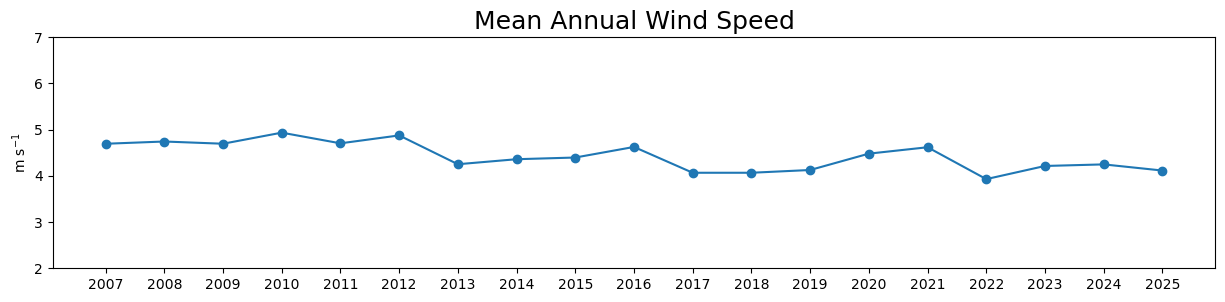

In [70]:
fig, ax = plt.subplots(figsize=(15, 3))
bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 0.9}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]

x=['2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022',
  '2023','2024','2025']
y=[Annual2007,Annual2008,Annual2009,Annual2010,Annual2011,Annual2012,Annual2013,Annual2014,Annual2015,\
   Annual2016,Annual2017,Annual2018,Annual2019,Annual2020,Annual2021,Annual2022,Annual2023,Annual2024,Annual2025]


ax.plot(x, y,marker='o',label='')

ax.set_title('Mean Annual Wind Speed',fontsize=18)  #(with 2015)
ax.legend((),frameon=False)
ax.set_ylim(2,7)
ax.set_ylabel('m s$^{-1}$')


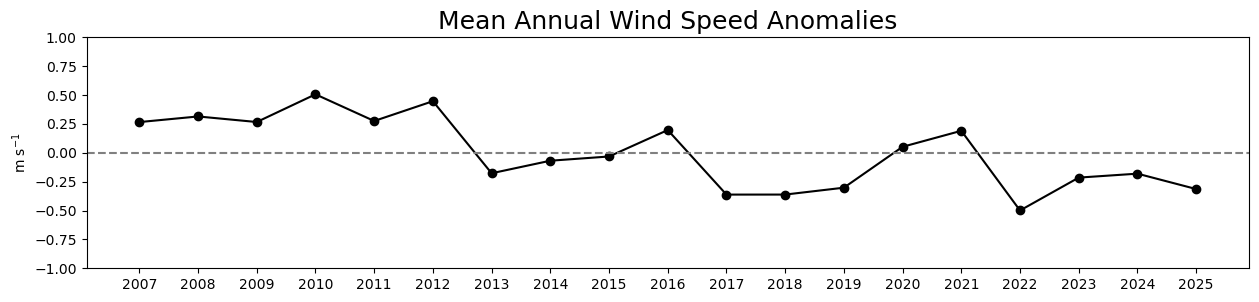

In [71]:
fig, ax = plt.subplots(figsize=(15, 3))
bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 0.9}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]

x=['2007','2008','2009','2010','2011','2012','2013','2014','2015','2016',
   '2017','2018','2019','2020','2021','2022','2023','2024','2025']
y=[Annual2007-AnnualClimatology,Annual2008-AnnualClimatology,Annual2009-AnnualClimatology,\
Annual2010-AnnualClimatology,Annual2011-AnnualClimatology,Annual2012-AnnualClimatology,\
Annual2013-AnnualClimatology,Annual2014-AnnualClimatology,Annual2015-AnnualClimatology,\
Annual2016-AnnualClimatology,Annual2017-AnnualClimatology,Annual2018-AnnualClimatology,\
Annual2019-AnnualClimatology,Annual2020-AnnualClimatology,Annual2021-AnnualClimatology,Annual2022-AnnualClimatology,\
   Annual2023-AnnualClimatology,Annual2024-AnnualClimatology,Annual2025-AnnualClimatology]


ax.plot(x, y,marker='o',label='',color='k')
#ax.bar(x,y,color='k')

ax.set_title('Mean Annual Wind Speed Anomalies',fontsize=18)  #(with 2015)
ax.legend((),frameon=False)
ax.set_ylim(-1,1)
ax.set_ylabel('m s$^{-1}$')
ax.axhline(y=0,color='grey',linestyle='--')


In [72]:
print(Annual2007-AnnualClimatology,Annual2008-AnnualClimatology,Annual2009-AnnualClimatology,\
Annual2010-AnnualClimatology,Annual2011-AnnualClimatology,Annual2012-AnnualClimatology,\
Annual2013-AnnualClimatology,Annual2014-AnnualClimatology,Annual2015-AnnualClimatology,\
Annual2016-AnnualClimatology,Annual2017-AnnualClimatology,Annual2018-AnnualClimatology,\
Annual2019-AnnualClimatology,Annual2020-AnnualClimatology,Annual2021-AnnualClimatology,Annual2022-AnnualClimatology,\
     Annual2023-AnnualClimatology,Annual2024-AnnualClimatology,Annual2025-AnnualClimatology)

0.26581986632662424 0.31443936784510473 0.2663268164738488 0.5061981594507365 0.27519789496505975 0.44658175269211053 -0.17731866082107306 -0.06870827642905741 -0.03214209120030542 0.19676740129237036 -0.3620218519424929 -0.36182539503331324 -0.30225826144770096 0.05182321031336645 0.1903348680282102 -0.4995226148819456 -0.21494198135539033 -0.18079391851037752 -0.31395628576578893


## Plot the coldest and warmest years only; Supp Fig. S5

/tmp/ipykernel_1612566/2438730060.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x)


[Text(0, 0, 'Jan'),
 Text(1, 0, 'Feb'),
 Text(2, 0, 'Mar'),
 Text(3, 0, 'Apr'),
 Text(4, 0, 'May'),
 Text(5, 0, 'Jun'),
 Text(6, 0, 'Jul'),
 Text(7, 0, 'Aug'),
 Text(8, 0, 'Sep'),
 Text(9, 0, 'Oct'),
 Text(10, 0, 'Nov'),
 Text(11, 0, 'Dec')]

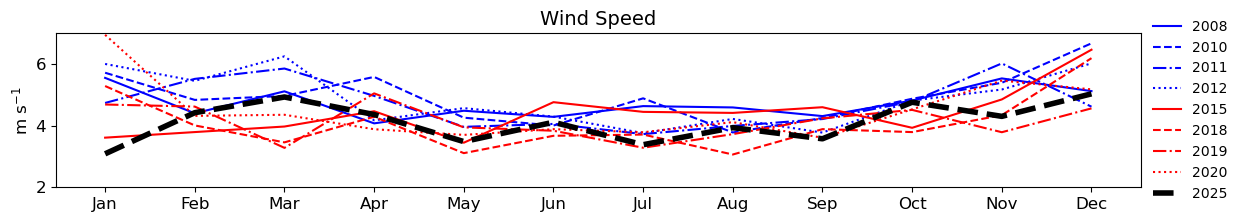

In [74]:
fig, ax = plt.subplots(figsize=(14, 2))
bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 0.9}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]


x=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
y1=[None,Feb2007,Mar2007,Apr2007,May2007,Jun2007,Jul2007,Aug2007,Sep2007,Oct2007,Nov2007,Dec2007]
y2=[Jan2008,Feb2008,Mar2008,Apr2008,May2008,Jun2008,Jul2008,Aug2008,Sep2008,Oct2008,Nov2008,Dec2008]
y3=[Jan2009,Feb2009,Mar2009,Apr2009,May2009,Jun2009,Jul2009,Aug2009,Sep2009,Oct2009,Nov2009,Dec2009]
y4=[Jan2010,Feb2010,Mar2010,Apr2010,May2010,Jun2010,Jul2010,Aug2010,Sep2010,Oct2010,Nov2010,Dec2010]
y5=[Jan2011,Feb2011,Mar2011,Apr2011,May2011,Jun2011,Jul2011,Aug2011,Sep2011,Oct2011,Nov2011,Dec2011]
y6=[Jan2012,Feb2012,Mar2012,Apr2012,May2012,Jun2012,Jul2012,Aug2012,Sep2012,Oct2012,Nov2012,Dec2012]
y7=[Jan2013,Feb2013,Mar2013,Apr2013,May2013,Jun2013,Jul2013,Aug2013,Sep2013,Oct2013,Nov2013,Dec2013]
y8=[Jan2014,Feb2014,Mar2014,Apr2014,May2014,Jun2014,Jul2014,Aug2014,Sep2014,Oct2014,Nov2014,None]
y9=[Jan2015,Feb2015,Mar2015,Apr2015,May2015,Jun2015,Jul2015,Aug2015,Sep2015,Oct2015,Nov2015,Dec2015]
y10=[Jan2016,Feb2016,Mar2016,Apr2016,May2016,Jun2016,Jul2016,Aug2016,Sep2016,Oct2016,Nov2016,Dec2016]
y11=[Jan2017,Feb2017,Mar2017,Apr2017,May2017,Jun2017,Jul2017,Aug2017,Sep2017,Oct2017,Nov2017,Dec2017]
y12=[Jan2018,Feb2018,Mar2018,Apr2018,May2018,Jun2018,Jul2018,Aug2018,Sep2018,Oct2018,Nov2018,Dec2018]
y13=[Jan2019,Feb2019,Mar2019,Apr2019,May2019,Jun2019,Jul2019,Aug2019,Sep2019,Oct2019,Nov2019,Dec2019]
y14=[Jan2020,Feb2020,Mar2020,Apr2020,May2020,Jun2020,Jul2020,Aug2020,Sep2020,Oct2020,Nov2020,Dec2020]
y15=[Jan2024,Feb2024,Mar2024,Apr2024,May2024,Jun2024,Jul2024,Aug2024,Sep2024,Oct2024,Nov2024,Dec2024]
y16=[Jan2025,Feb2025,Mar2025,Apr2025,May2025,Jun2025,Jul2025,Aug2025,Sep2025,Oct2025,Nov2025,Dec2025]


#ax.plot(x, y1,label='2007')
ax.plot(x, y2,label='2008',color='b',linestyle='-')
#ax.plot(x, y3,label='2009')
ax.plot(x, y4,label='2010',color='b',linestyle='--')
ax.plot(x, y5,label='2011',color='b',linestyle='-.')
ax.plot(x, y6,label='2012',color='b',linestyle=':')
#ax.plot(x, y7,label='2013')
#ax.plot(x, y8,label='2014',linestyle='--'
#ax.plot(x, y9,label='2015',linestyle='--')
#ax.plot(x, y10,label='2016',linestyle='--')
ax.plot(x, y9,label='2015',color='r',linestyle='-')
ax.plot(x, y12,label='2018',color='r',linestyle='--')
ax.plot(x, y13,label='2019',color='r',linestyle='-.')
ax.plot(x, y14,label='2020',color='r',linestyle=':')
ax.plot(x, y16,label='2025',color='k',linewidth=4,linestyle='--')

ax.set_title('Wind Speed',fontsize=14)
ax.legend(frameon=False,loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_ylim(2,7)
ax.set_ylabel('m s$^{-1}$',fontsize=12)
ax.xaxis.set_tick_params(labelsize=12)
ax.yaxis.set_tick_params(labelsize=12)
ax.set_xticklabels(x)

### Select 4 warmest and 4 coldest years; leave NPGO "neutral" years out

In [75]:
Jan_W=(Jan2015+Jan2018+Jan2019+Jan2020)/4
Feb_W=(Feb2015+Feb2018+Feb2019+Jan2020)/4
Mar_W=(Mar2015+Mar2018+Mar2019+Mar2020)/4
Apr_W=(Apr2015+Apr2018+Apr2019+Apr2020)/4
May_W=(May2015+May2018+May2019+May2020)/4
Jun_W=(Jun2015+Jun2018+Jun2019+Jun2020)/4
Jul_W=(Jul2015+Jul2018+Jul2019+Jul2020)/4
Aug_W=(Aug2015+Aug2018+Aug2019+Aug2020)/4
Sep_W=(Sep2015+Sep2018+Sep2019+Sep2020)/4
Oct_W=(Oct2015+Oct2018+Oct2019+Oct2020)/4
Nov_W=(Nov2015+Nov2018+Nov2019+Nov2020)/4
Dec_W=(Dec2015+Dec2018+Dec2019+Dec2020)/4

In [76]:
Jan_C=(Jan2008+Jan2010+Jan2011+Jan2012)/4
Feb_C=(Feb2008+Feb2010+Feb2011+Jan2012)/4
Mar_C=(Mar2008+Mar2010+Mar2011+Mar2012)/4
Apr_C=(Apr2008+Apr2010+Apr2011+Apr2012)/4
May_C=(May2008+May2010+May2011+May2012)/4
Jun_C=(Jun2008+Jun2010+Jun2011+Jun2012)/4
Jul_C=(Jul2008+Jul2010+Jul2011+Jul2012)/4
Aug_C=(Aug2008+Aug2010+Aug2011+Aug2012)/4
Sep_C=(Sep2008+Sep2010+Sep2011+Sep2012)/4
Oct_C=(Oct2008+Oct2010+Oct2011+Oct2012)/4
Nov_C=(Nov2008+Nov2010+Nov2011+Nov2012)/4
Dec_C=(Dec2008+Dec2010+Dec2011+Dec2012)/4

### Assign years so that SEM can be calculated

In [77]:
Jan_W_years=(Jan2015,Jan2018,Jan2019,Jan2020)
Feb_W_years=(Feb2015,Feb2018,Feb2019,Jan2020)
Mar_W_years=(Mar2015,Mar2018,Mar2019,Mar2020)
Apr_W_years=(Apr2015,Apr2018,Apr2019,Apr2020)
May_W_years=(May2015,May2018,May2019,May2020)
Jun_W_years=(Jun2015,Jun2018,Jun2019,Jun2020)
Jul_W_years=(Jul2015,Jul2018,Jul2019,Jul2020)
Aug_W_years=(Aug2015,Aug2018,Aug2019,Aug2020)
Sep_W_years=(Sep2015,Sep2018,Sep2019,Sep2020)
Oct_W_years=(Oct2015,Oct2018,Oct2019,Oct2020)
Nov_W_years=(Nov2015,Nov2018,Nov2019,Nov2020)
Dec_W_years=(Dec2015,Dec2018,Dec2019,Dec2020)

In [78]:
Jan_C_years=(Jan2008,Jan2010,Jan2011,Jan2012)
Feb_C_years=(Feb2008,Feb2010,Feb2011,Jan2012)
Mar_C_years=(Mar2008,Mar2010,Mar2011,Mar2012)
Apr_C_years=(Apr2008,Apr2010,Apr2011,Apr2012)
May_C_years=(May2008,May2010,May2011,May2012)
Jun_C_years=(Jun2008,Jun2010,Jun2011,Jun2012)
Jul_C_years=(Jul2008,Jul2010,Jul2011,Jul2012)
Aug_C_years=(Aug2008,Aug2010,Aug2011,Aug2012)
Sep_C_years=(Sep2008,Sep2010,Sep2011,Sep2012)
Oct_C_years=(Oct2008,Oct2010,Oct2011,Oct2012)
Nov_C_years=(Nov2008,Nov2010,Nov2011,Nov2012)
Dec_C_years=(Dec2008,Dec2010,Dec2011,Dec2012)

In [79]:
from scipy.stats import sem

/tmp/ipykernel_1612566/35014756.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x)


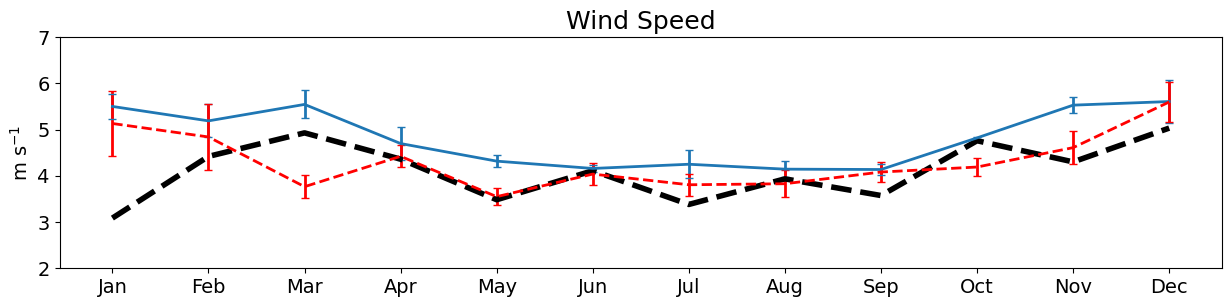

In [80]:
## Preliminary Figure 4e

fig, ax = plt.subplots(figsize=(15, 3))
bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 0.9}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]

x=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
y=[Jan_C,Feb_C,Mar_C,Apr_C,May_C,Jun_C,Jul_C,Aug_C,Sep_C,Oct_C,Nov_C,Dec_C]
y2=[Jan_W,Feb_W,Mar_W,Apr_W,May_W,Jun_W,Jul_W,Aug_W,Sep_W,Oct_W,Nov_W,Dec_W]
err1=[sem(Jan_C_years),sem(Feb_C_years),sem(Mar_C_years),sem(Apr_C_years),sem(May_C_years),sem(Jun_C_years),\
     sem(Jul_C_years),sem(Aug_C_years),sem(Sep_C_years),sem(Oct_C_years),sem(Nov_C_years),sem(Dec_C_years)]
err2=[sem(Jan_W_years),sem(Feb_W_years),sem(Mar_W_years),sem(Apr_W_years),sem(May_W_years),sem(Jun_W_years),\
     sem(Jul_W_years),sem(Aug_W_years),sem(Sep_W_years),sem(Oct_W_years),sem(Nov_W_years),sem(Dec_W_years)]
y3=[Jan2025,Feb2025,Mar2025,Apr2025,May2025,Jun2025,Jul2025,Aug2025,Sep2025,Oct2025,Nov2025,Dec2025]

ax.errorbar(x, y, yerr= err1, capsize=3,label='NPGO+ coldest',linewidth=2)
ax.errorbar(x, y2,yerr= err2, capsize=3,linestyle='--',label='NPGO- warmest',color='r',linewidth=2)
ax.plot(x, y3,color='k',linewidth=4,linestyle='--',label='2025')

ax.set_title('Wind Speed',fontsize=18)  #(with 2015)
ax.legend((),frameon=False)
ax.set_ylim(2,7)
ax.set_ylabel('m s$^{-1}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_xticklabels(x)

a=2
b=5
c=5
d=8
#plt.fill([a, a, b, b], [0, 200, 200, 0], color = 'lightgreen', alpha = 0.1)
#plt.fill([c, c, d, d], [0, 200, 200, 0], color = 'wheat', alpha = 0.2)
#ax.text(-.4, 6, '(e)', fontsize=15,  color='k')

#plt.savefig('Fig3e_Wind.png', bbox_inches='tight',dpi=1000,transparent=False)

In [81]:
Spring2007=(Mar2007+Apr2007+May2007)/3
Spring2008=(Mar2008+Apr2008+May2008)/3
Spring2009=(Mar2009+Apr2009+May2009)/3
Spring2010=(Mar2010+Apr2010+May2010)/3
Spring2011=(Mar2011+Apr2011+May2011)/3
Spring2012=(Mar2012+Apr2012+May2012)/3
Spring2013=(Mar2013+Apr2013+May2013)/3
Spring2014=(Mar2014+Apr2014+May2014)/3
Spring2015=(Mar2015+Apr2015+May2015)/3
Spring2016=(Mar2016+Apr2016+May2016)/3
Spring2017=(Mar2017+Apr2017+May2017)/3
Spring2018=(Mar2018+Apr2018+May2018)/3
Spring2019=(Mar2019+Apr2019+May2019)/3
Spring2020=(Mar2020+Apr2020+May2020)/3
Spring2021=(Mar2021+Apr2021+May2021)/3
Spring2022=(Mar2022+Apr2022+May2022)/3
Spring2023=(Mar2023+Apr2023+May2023)/3
Spring2024=(Mar2024+Apr2024+May2024)/3
Spring2025=(Mar2025+Apr2025+May2025)/3

In [82]:
SpringClimatology=(Spring2007+Spring2008+Spring2009+Spring2010+Spring2011+Spring2012+Spring2013+Spring2014+Spring2015+\
                  Spring2016+Spring2017+Spring2018+Spring2019+Spring2020+Spring2021+Spring2022+Spring2023+\
                  Spring2024+Spring2025)/19

In [83]:
print(Spring2007-SpringClimatology,Spring2008-SpringClimatology,Spring2009-SpringClimatology,\
Spring2010-SpringClimatology,Spring2011-SpringClimatology,Spring2012-SpringClimatology,\
Spring2013-SpringClimatology,Spring2014-SpringClimatology,Spring2015-SpringClimatology,\
Spring2016-SpringClimatology,Spring2017-SpringClimatology,Spring2018-SpringClimatology,\
Spring2019-SpringClimatology,Spring2020-SpringClimatology,Spring2021-SpringClimatology,Spring2022-SpringClimatology,\
     Spring2023-SpringClimatology,Spring2024-SpringClimatology,Spring2025-SpringClimatology)

0.313348356567527 0.16326290734877702 0.5397550897625143 0.5411509510702945 0.5330507593181784 0.6028301553753073 -0.043610668497576555 0.04235417016615983 -0.4321954412433451 0.2583057718303854 -0.1478838287962425 -0.7762175563149598 -0.3038111689858578 -0.41522893937160044 -0.05239877732326015 -0.29358015091945155 -0.44797847381780986 0.055188574991922756 -0.13634173116096804
